In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
    roc_curve,
    auc)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV)
from collections import Counter
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler)
import warnings
from imblearn.over_sampling import SMOTE
import ppscore as pps
from rich.console import Console
from tabulate import tabulate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd
# Set display options for better visualization
warnings.filterwarnings("ignore")
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
console = Console()

In [2]:
df = pd.read_csv("Data.csv")

In [3]:
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [4]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [6]:
# check for duplicates
df.duplicated().sum()

0

In [7]:
# check for nulls
df.isnull().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [8]:
# Check for outliers using the IQR method
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers in {col}: {len(outliers)}")

Outliers in Temperature: 92
Outliers in Humidity: 0
Outliers in Wind Speed: 404
Outliers in Precipitation (%): 0
Outliers in Atmospheric Pressure: 927
Outliers in UV Index: 0
Outliers in Visibility (km): 383


In [9]:
# Identify numerical and categorical variables
categorical_variables = df.select_dtypes(include=object).columns.tolist()
numeric_variables = df.select_dtypes(exclude=object).columns.tolist()
print("Categorical columns:", categorical_variables)
print("Numerical columns:", numeric_variables)
# Check unique values in categorical columns
for col in df.select_dtypes(include="object").columns:
    print(f"Unique values in {col}: {df[col].unique()}")

Categorical columns: ['Cloud Cover', 'Season', 'Location', 'Weather Type']
Numerical columns: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']
Unique values in Cloud Cover: ['partly cloudy' 'clear' 'overcast' 'cloudy']
Unique values in Season: ['Winter' 'Spring' 'Summer' 'Autumn']
Unique values in Location: ['inland' 'mountain' 'coastal']
Unique values in Weather Type: ['Rainy' 'Cloudy' 'Sunny' 'Snowy']


Seaborn Version: 0.13.2


<Axes: xlabel='Temperature', ylabel='Density'>

<Axes: xlabel='Temperature', ylabel='Density'>

<Axes: xlabel='Temperature', ylabel='Density'>

Text(0.5, 0, '')

...

<Axes: xlabel='Visibility (km)', ylabel='Density'>

<Axes: xlabel='Visibility (km)', ylabel='Density'>

<Axes: xlabel='Visibility (km)', ylabel='Density'>

Text(0.5, 0, '')

Text(0.5, 1.0, 'Visibility (km)')

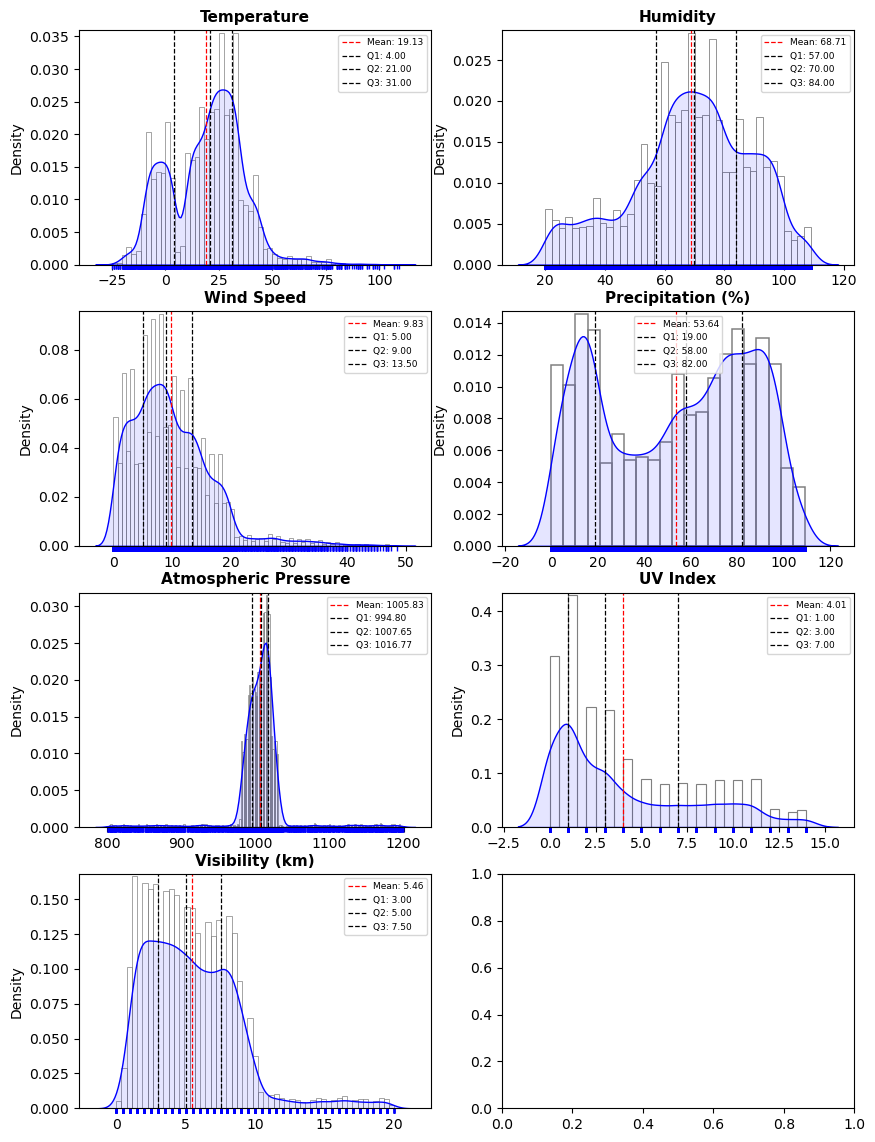

In [10]:
# Numerical Feature Distributions
print("Seaborn Version:", sns.__version__)
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(10, 14))
ax = ax.flatten()
for i, variable in enumerate(numeric_variables):
    if i < len(ax):  # Make sure we don't exceed the number of subplots
        mu = df[variable].mean()
        q1, q2, q3 = df[variable].quantile([0.25, 0.5, 0.75])
        df[variable] = df[variable].replace([np.inf, np.nan], np.nan)
        sns.histplot(df[variable].dropna(), stat="density", fill=False, color="gray",
                     ax=ax[i])
        sns.kdeplot(df, x=variable, fill=True, color="blue", ax=ax[i], alpha=0.1)

        sns.rugplot(df, x=variable, height=-0.02, clip_on=False, color="blue",
                     ax=ax[i])
        ax[i].axvline(mu, linestyle="--", linewidth=0.9, color="red", label=f"Mean: {mu:.2f}")
        ax[i].axvline(q1, linestyle="--", linewidth=0.9, color="black", label=f"Q1: {q1:.2f}")
        ax[i].axvline(q2, linestyle="--", linewidth=0.9, color="black", label=f"Q2: {q2:.2f}")
        ax[i].axvline(q3, linestyle="--", linewidth=0.9, color="black", label=f"Q3: {q3:.2f}")
        ax[i].set_xlabel("")
        ax[i].set_title(f"{variable}", fontweight="bold", color="black", fontsize=11)
        ax[i].legend(fontsize=6.5, loc="best")

In [ ]:
# Pairplot for Numerical Variables
graph = sns.PairGrid(df[numeric_variables], palette="dark")
graph.map_lower(sns.scatterplot, size=2.1, color="blue", alpha=0.4)
graph.map_upper(sns.kdeplot, fill=True, cmap="mako")
graph.map_diag(sns.histplot, fill=False, color="gray", kde=True, line_kws={"linewidth": 2.5})
plt.show()
# Correlation Matrix using Pearson method
corr_matrix_pearson = df[numeric_variables].corr(method="pearson")
mask = np.triu(np.ones_like(corr_matrix_pearson, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    corr_matrix_pearson,
    annot=True,
    annot_kws={"fontsize": 7, "fontweight": "bold"},
    fmt=".3f",
    linewidths=0.6,
    cmap="coolwarm",
    mask=mask,
    square=True,
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment="right")
ax.tick_params(labelsize=8, labelcolor="black")
ax.set_title("Correlation Matrix - Pearson", fontsize=12, fontweight="bold", color="black")
plt.tight_layout()
plt.show()

<Axes: xlabel='x', ylabel='y'>

[Text(0.5, 0, 'Atmospheric Pressure'),
 Text(1.5, 0, 'Cloud Cover'),
 Text(2.5, 0, 'Humidity'),
 Text(3.5, 0, 'Location'),
 Text(4.5, 0, 'Precipitation (%)'),
 Text(5.5, 0, 'Season'),
 Text(6.5, 0, 'Temperature'),
 Text(7.5, 0, 'UV Index'),
 Text(8.5, 0, 'Visibility (km)'),
 Text(9.5, 0, 'Weather Type'),
 Text(10.5, 0, 'Wind Speed')]

Text(0.5, 1.0, 'Predictive Power Score (PPS)')

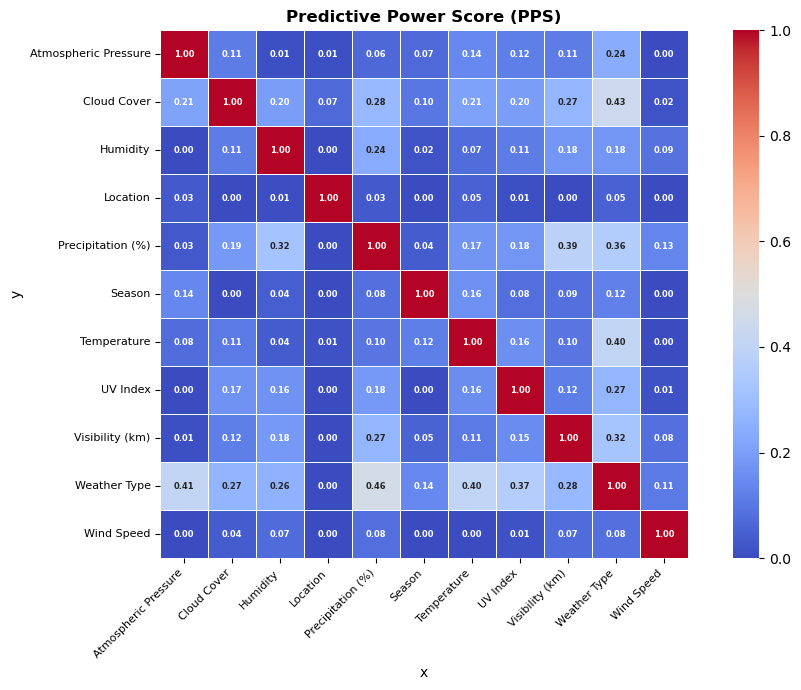

In [20]:
# Predictive Power Score Analysis
pps_scores = []
columns = df.columns
for col_y in columns:
    for col_x in columns:
        pps_value = pps.score(df, col_x, col_y)["ppscore"]
        pps_scores.append({"x": col_x, "y": col_y, "ppscore": pps_value})
# Convert list to DataFrame
pps_df = pd.DataFrame(pps_scores)
# Convert DataFrame into a heatmap-friendly matrix
pps_matrix = pps_df.pivot(index="y", columns="x", values="ppscore")
# Create the heatmap
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    pps_matrix,
    annot=True,
    annot_kws={"fontsize": 6.0, "fontweight": "bold"},
    fmt=".2f",
    linewidths=0.6,
    cmap="coolwarm",
    square=True, ax=ax,
)
# Format the labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.tick_params(labelsize=8, labelcolor="black")
ax.set_title("Predictive Power Score (PPS)", fontsize=12, fontweight="bold", color="black")
plt.tight_layout()
plt.show()

<Axes: xlabel='Temperature', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of Temperature')

<Axes: xlabel='Humidity', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of Humidity')

<Axes: xlabel='Wind Speed', ylabel='Count'>

...

Text(0.5, 1.0, 'Distribution of Precipitation (%)')

<Axes: xlabel='UV Index', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of UV Index')

<Axes: xlabel='Visibility (km)', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of Visibility (km)')

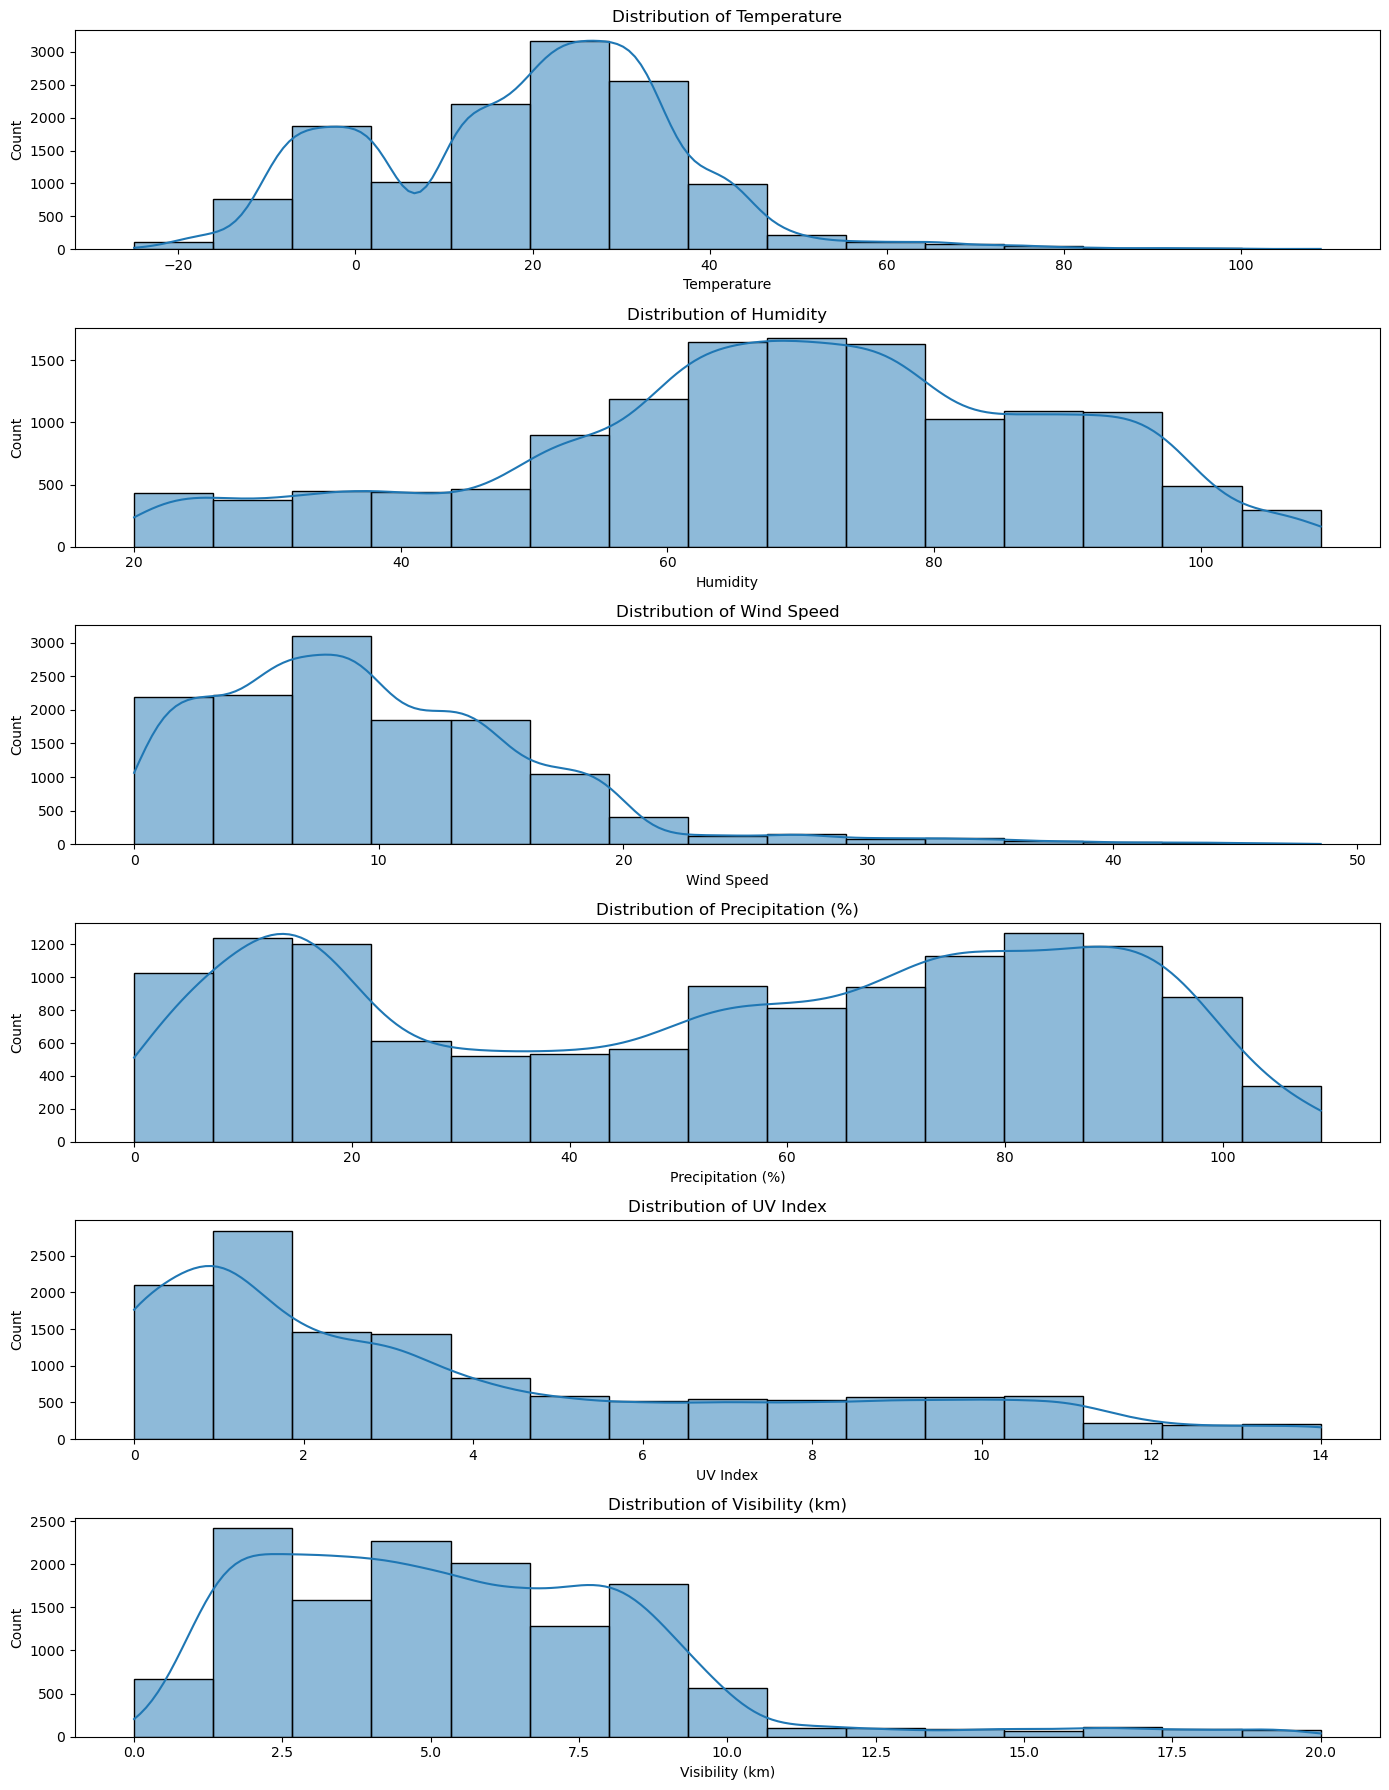

In [21]:
# Distribution plots for numerical features
num_cols = [
    "Temperature",
    "Humidity",
    "Wind Speed",
    "Precipitation (%)",
    "UV Index",
    "Visibility (km)",
]
fig, axes = plt.subplots(nrows=len(num_cols), ncols=1, figsize=(14, 18))
for i, column in enumerate(num_cols):
    sns.histplot(df[column], kde=True, ax=axes[i], bins=15)
    axes[i].set_title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

<Figure size 1400x700 with 0 Axes>

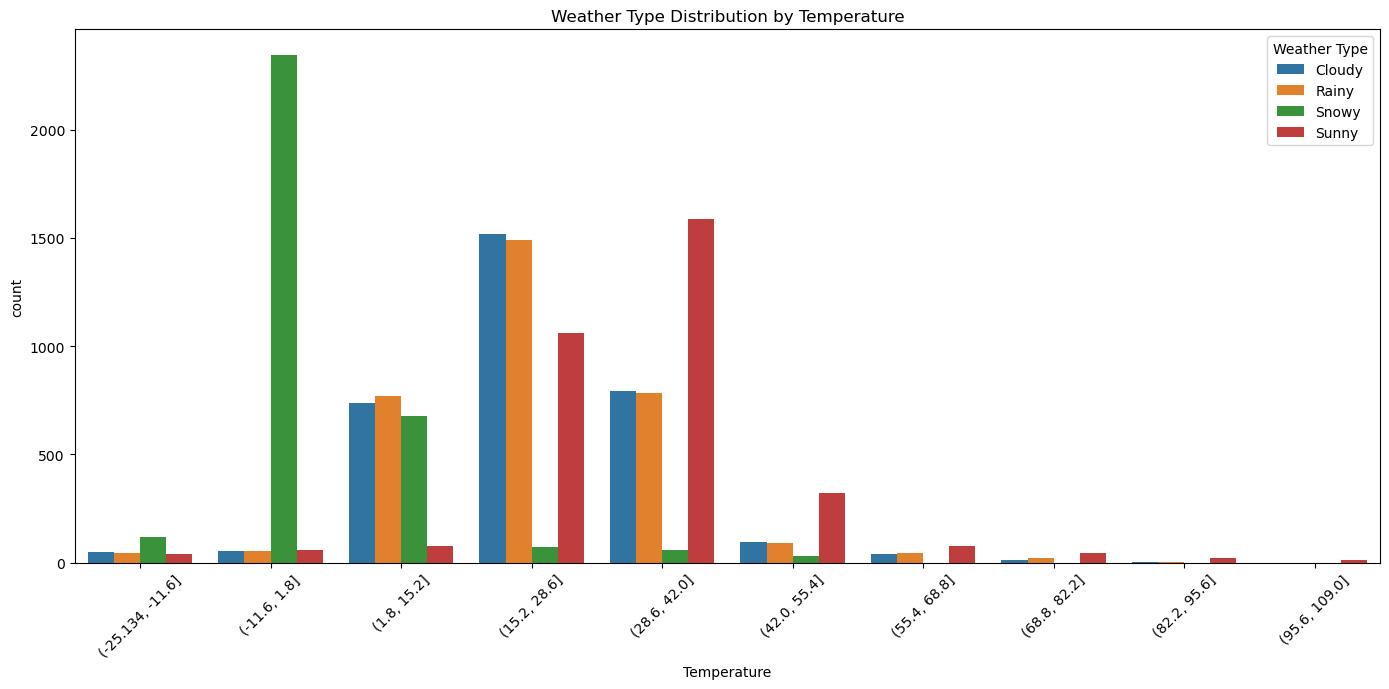

<Figure size 1400x700 with 0 Axes>

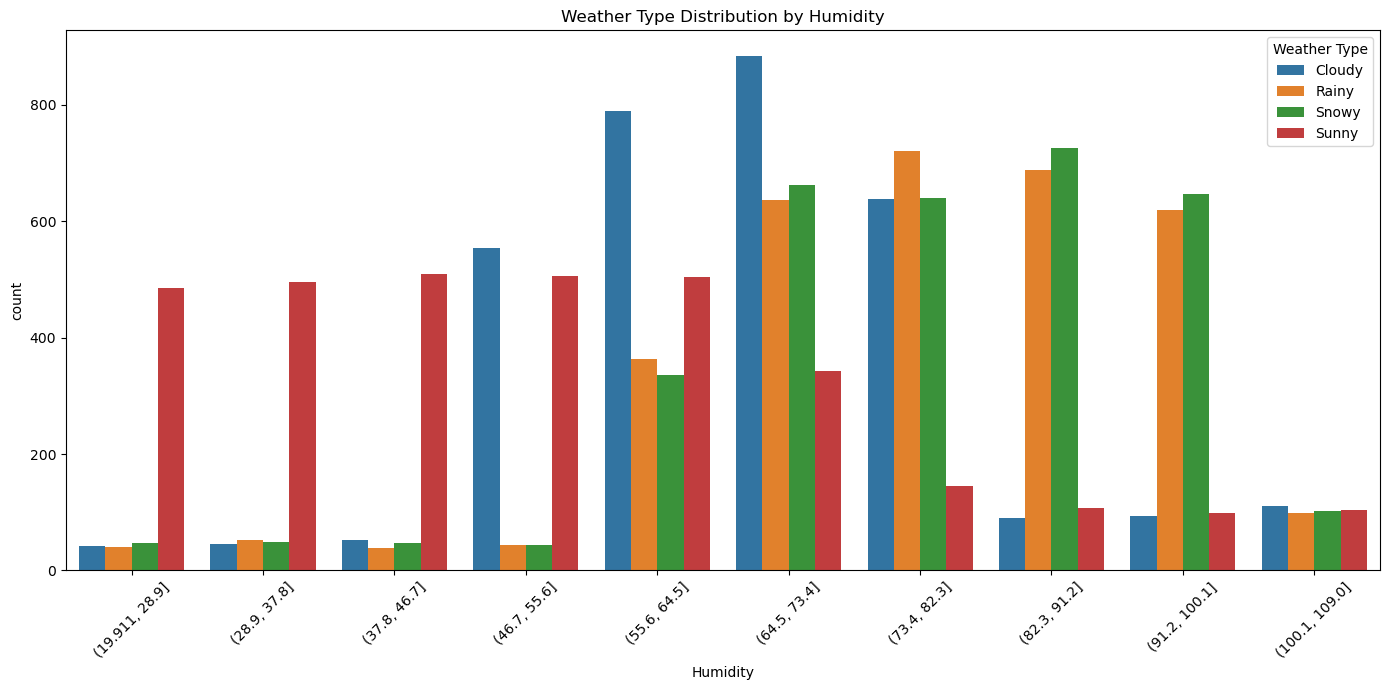

<Figure size 1400x700 with 0 Axes>

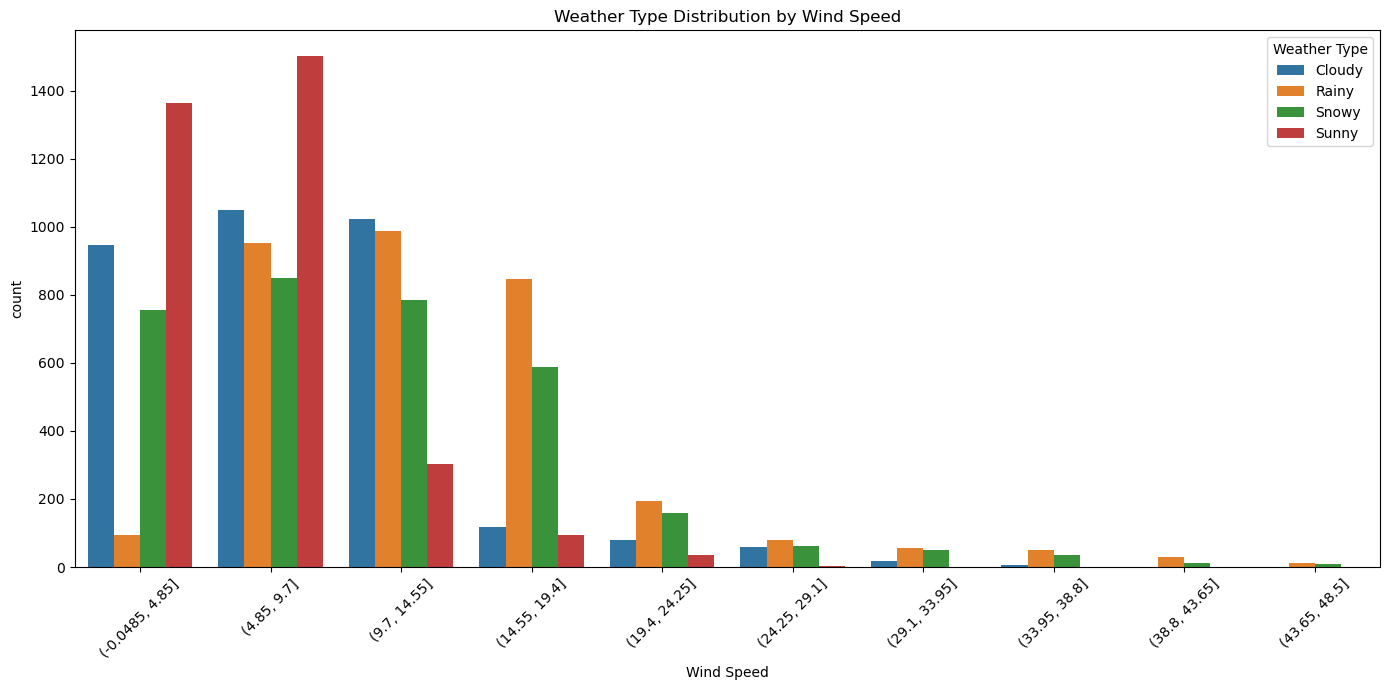

<Figure size 1400x700 with 0 Axes>

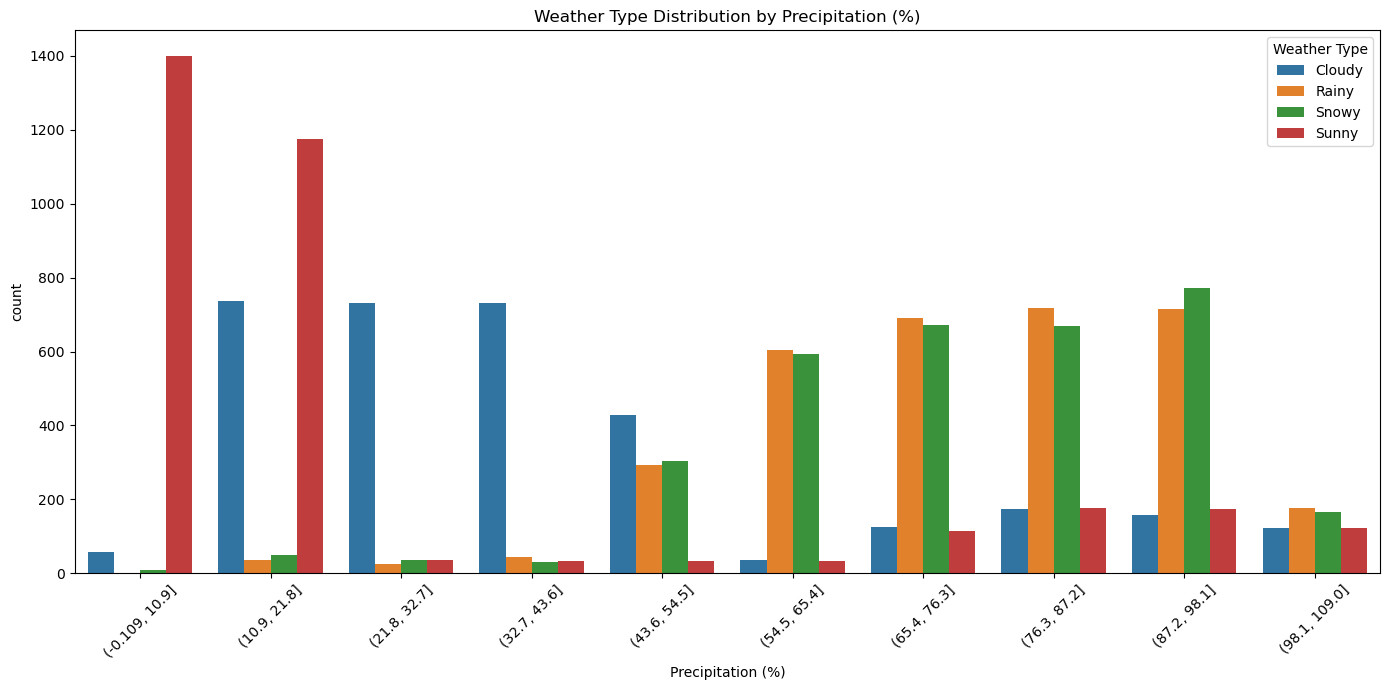

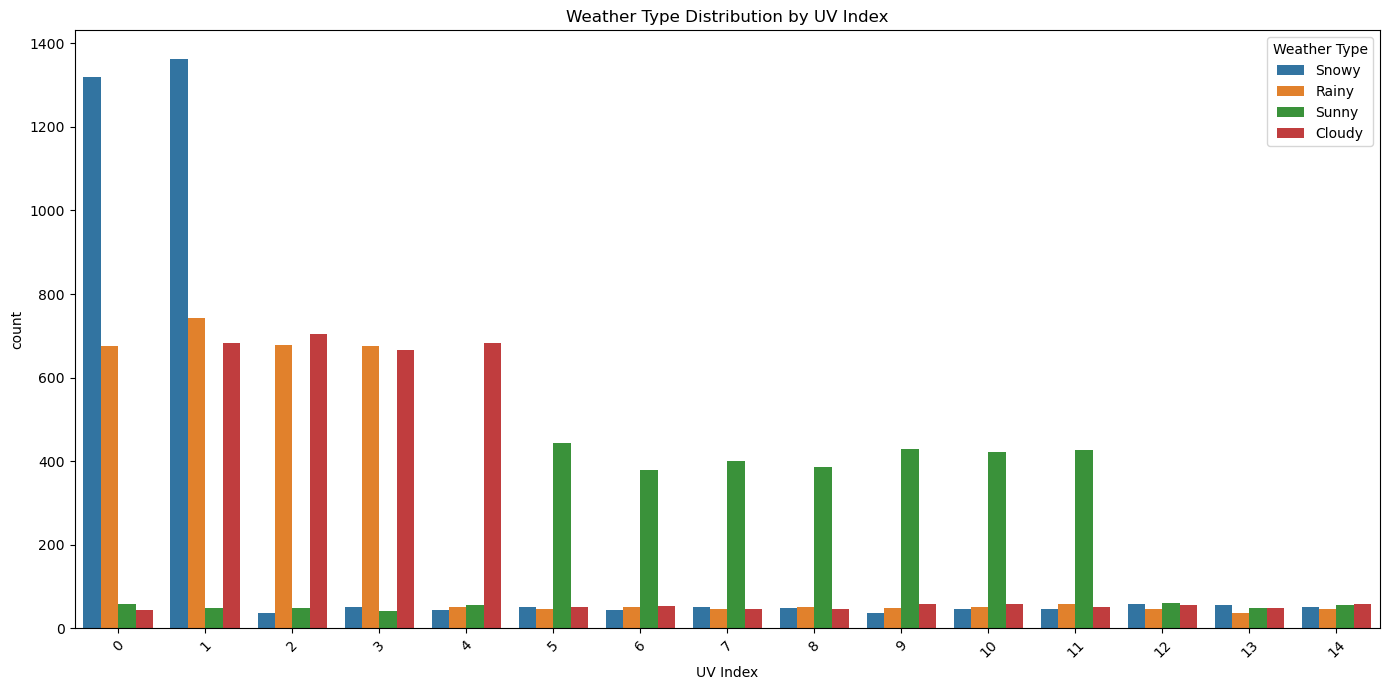

<Figure size 1400x700 with 0 Axes>

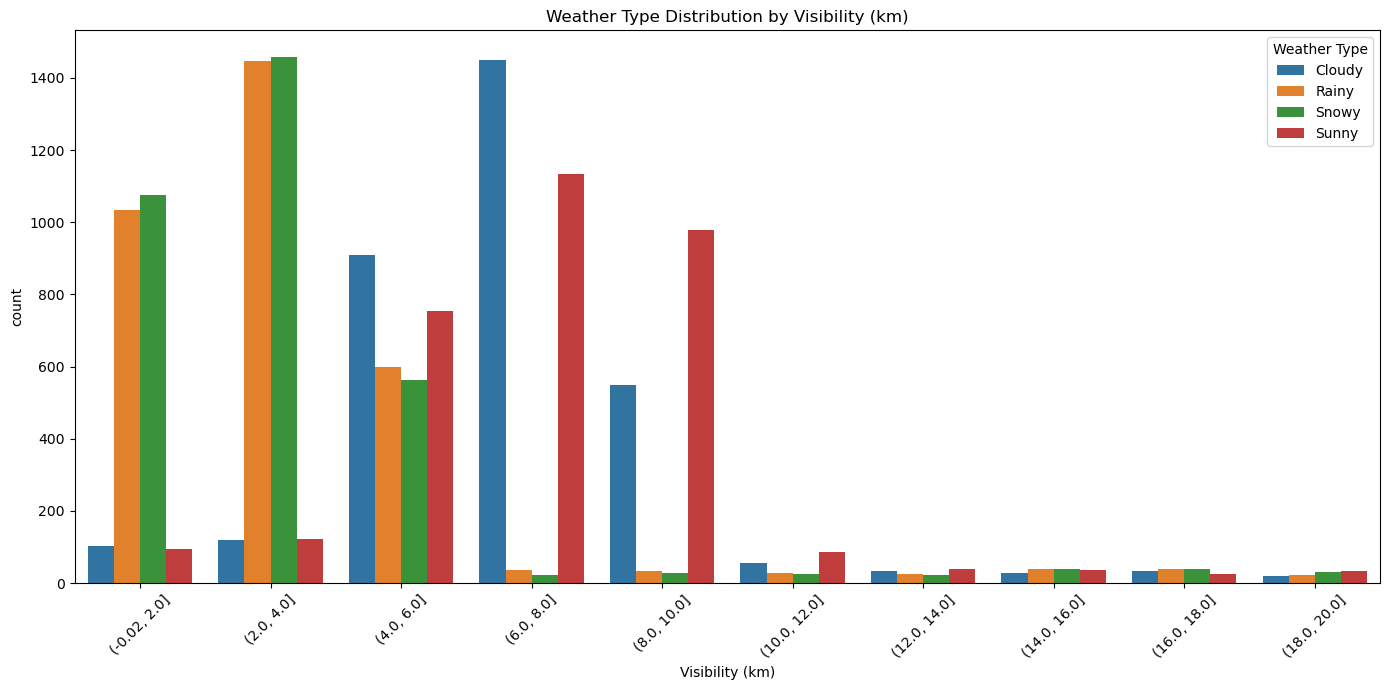

X_train: 9504 samples
X_val: 1056 samples
X_test: 2640 samples


In [22]:
#Weather Type Distribution by Numerical Features

def plot_weather_by_feature(feature_name, df, bins=10):
    plt.figure(figsize=(14, 7))
    # Bin the continuous features
    if df[feature_name].nunique() > 20:
        bins = pd.cut(df[feature_name], bins=bins)
        # Group by bins and weather type, count occurrences
        grouped = df.groupby([bins, 'Weather Type']).size().reset_index(name='count')
        # Convert bins to string for better display
        grouped.rename(columns={bins.name: feature_name}, inplace=True)
        grouped[feature_name] = grouped[feature_name].astype(str)
        # Plotting
        plt.figure(figsize=(14, 7))
        sns.barplot(x=feature_name, y='count', hue='Weather Type', data=grouped)

    else:
        # For features with fewer unique values, use the original values
        sns.countplot(x=feature_name, hue='Weather Type', data=df)
    plt.title(f"Weather Type Distribution by {feature_name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
# Plot distributions for numerical features
for col in num_cols:
    plot_weather_by_feature(col, df)
# Data Splitting
X = df.drop(columns=["Weather Type"])
y = df["Weather Type"]
# First, split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
# Then, split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=0,
                                                    stratify=y_train)
print(f"X_train: {len(X_train)} samples")
print(f"X_val: {len(X_val)} samples")
print(f"X_test: {len(X_test)} samples")

In [23]:
# Feature Preprocessing
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

In [24]:
# Preprocessing using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features,
        ),  # Scale numerical features
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),  # One-hot encode categorical features
    ],
    remainder="drop",
)

In [25]:
# Fit and transform the data
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)
# Get feature names after transformation
feature_names = ([f"num__{col}" for col in numeric_features] + [f"cat__{val}" for col in categorical_features for val in df[col].unique()])

In [26]:
# After transforming, convert to DataFrames
X_train_df = pd.DataFrame(X_train_processed, columns=preprocessor.get_feature_names_out())
X_val_df = pd.DataFrame(X_val_processed, columns=preprocessor.get_feature_names_out())
X_test_df = pd.DataFrame(X_test_processed, columns=preprocessor.get_feature_names_out())
print("Shape of X_train after preprocessing:", X_train_df.shape)
print("Shape of X_val after preprocessing:", X_val_df.shape)
print("Shape of X_test after preprocessing:", X_test_df.shape)

Shape of X_train after preprocessing: (9504, 18)
Shape of X_val after preprocessing: (1056, 18)
Shape of X_test after preprocessing: (2640, 18)


In [27]:
# Apply SMOTE for oversampling
smote = SMOTE(random_state=0)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_df, y_train)
# Check class distribution after balancing
print("Class distribution after balancing:", Counter(y_train_resampled))

Class distribution after balancing: Counter({'Rainy': 2376, 'Snowy': 2376, 'Cloudy': 2376, 'Sunny': 2376})


In [28]:
# Update training data
X_train_df = X_train_resampled
y_train = y_train_resampled

In [29]:
# Encode labels after resampling
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)
print("Training set class distribution:", Counter(y_train))
print("Validation set class distribution:", Counter(y_val))
print("Test set class distribution:", Counter(y_test))

Training set class distribution: Counter({1: 2376, 2: 2376, 0: 2376, 3: 2376})
Validation set class distribution: Counter({0: 264, 3: 264, 1: 264, 2: 264})
Test set class distribution: Counter({2: 660, 0: 660, 1: 660, 3: 660})


In [30]:
# Define the Classification models for our weather classification task
MODELS = { "LogisticRegression": LogisticRegression(random_state=0, max_iter=1000),
    "SVC": SVC(random_state=0, probability=True),
    "RandomForestClassifier": RandomForestClassifier(random_state=0, n_jobs=-1),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=0),
    "XGBClassifier": XGBClassifier(random_state=0, n_jobs=-1, use_label_encoder=False,
                                    eval_metric="mlogloss"),
    "LGBMClassifier": LGBMClassifier(random_state=0, n_jobs=-1, verbosity=-1),
    "CatBoostClassifier": CatBoostClassifier(random_state=0, thread_count=-1, verbose=0),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=0),
    "KNeighborsClassifier": KNeighborsClassifier(n_jobs=-1)}

In [31]:
# Define parameter grids for hyperparameter tuning
PARAM_GRIDS = {
    "LogisticRegression": {"classifier__C": [0.1, 1, 10], "classifier__solver": ["liblinear",
                                                                                    "saga"]},
    "SVC": {"classifier__C": [0.1, 1, 10], "classifier__kernel": ["rbf", "linear"]},
    "RandomForestClassifier": {"classifier__n_estimators": [50, 100, 200],
                               "classifier__max_depth": [3, 5, 7]},
    "GradientBoostingClassifier": {"classifier__n_estimators": [50, 100, 200],
                                   "classifier__learning_rate": [0.01, 0.1]},
    "XGBClassifier": {"classifier__n_estimators": [50, 100], "classifier__learning_rate": [
        0.01, 0.1], "classifier__max_depth": [3, 5]},
    "LGBMClassifier": {"classifier__n_estimators": [50, 100], "classifier__learning_rate": [
        0.01, 0.1], "classifier__max_depth": [3, 5]},
    "CatBoostClassifier": {"classifier__iterations": [50, 100], "classifier__learning_rate": [
        0.01, 0.1], "classifier__depth": [3, 5]},
    "DecisionTreeClassifier": {"classifier__max_depth": [3, 5, 7, 10],
                               "classifier__min_samples_split": [2, 5, 10]},
    "KNeighborsClassifier": {"classifier__n_neighbors": [3, 5, 7, 9],
                             "classifier__weights": ["uniform", "distance"]}}

In [32]:
# Store results for a table
results = []
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

In [33]:
#Function to plot ROC Curve
def plot_roc_curve(y_true, y_score, class_names):
    n_classes = len(class_names)
    # Binarize the labels
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    # Compute ROC curve and ROC area for each class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    # Plot micro-average ROC curve
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.2f})',
             color='deeppink', linestyle=':', linewidth=4)
    # Colors for different classes
    colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))
    # Plot ROC curves for all classes
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')
    # Plot diagonal line
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    return plt

In [35]:
# Function to plot hyperparameter tuning results
def plot_param_tuning(cv_results, param_name, title):

    # Extract parameter values
    param_values = sorted(cv_results[f'param_{param_name}'].data)
    unique_values = sorted(list(set(param_values)))
    
    # Extract scores
    train_scores = []
    test_scores = []
    
    for value in unique_values:
        # Get indices of results with this parameter value
        indices = [i for i, v in enumerate(param_values) if v == value]
        
        # Extract corresponding train and test scores
        train_scores.append(np.mean([cv_results[f'mean_train_score'][i] for i in indices]))
        test_scores.append(np.mean([cv_results[f'mean_test_score'][i] for i in indices]))
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(unique_values, train_scores, 'o-', label='Training score')
    plt.plot(unique_values, test_scores, 'o-', label='Validation score')
    plt.xlabel(param_name)
    plt.ylabel('Score')
    plt.title(f'Effect of {param_name} on {title}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    return plt

  0%|                                                     | 0/9 [00:00<?, ?it/s]

───────────────────────────────────────────  Model: LogisticRegression  ───────────────────────────────────────────

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=0))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.1, 1, 10],
                         'classifier__solver': ['liblinear', 'saga']},
             return_train_score=True, scoring='accuracy')

Classification Report for LogisticRegression:


              precision    recall  f1-score   support

           0       0.82      0.81      0.81       660
           1       0.82      0.83      0.83       660
           2       0.88      0.91      0.89       660
           3       0.91      0.87      0.89       660

    accuracy                           0.86      2640
   macro avg       0.86      0.86      0.86      2640
weighted avg       0.86      0.86      0.86      2640



Best parameters found: {'classifier__C': 10, 'classifier__solver': 'saga'}

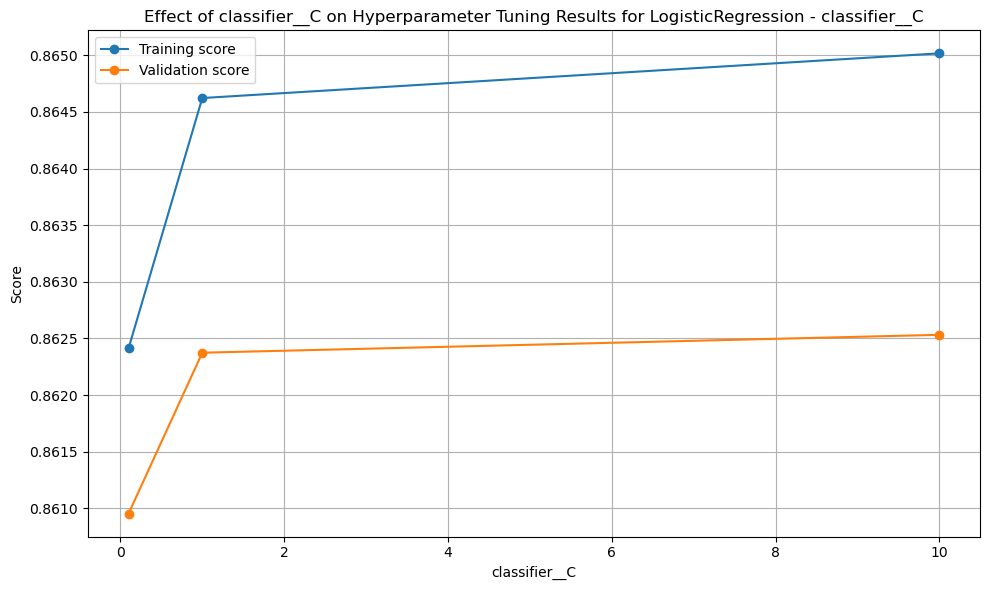

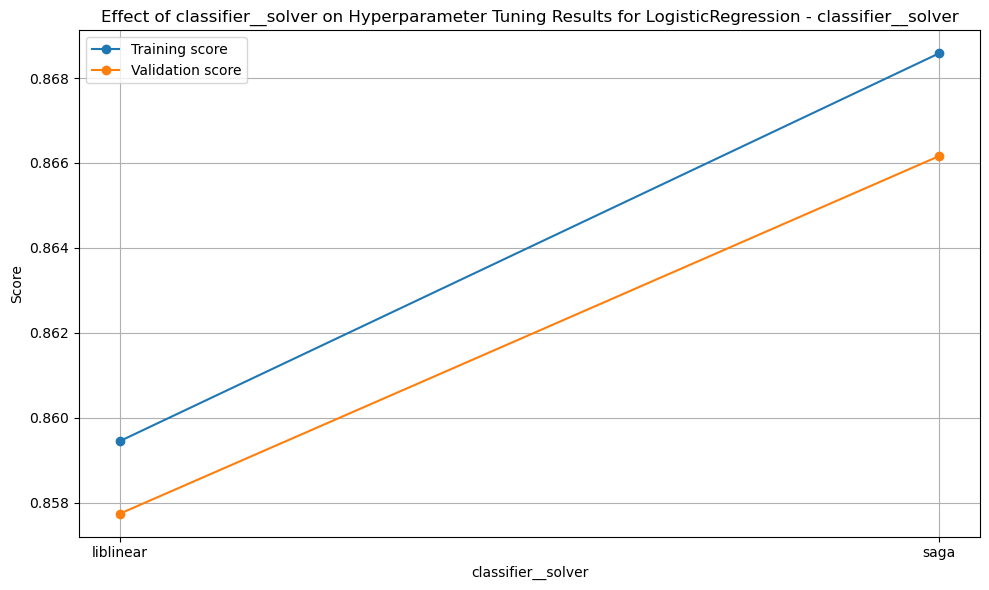

Confusion Matrix for LogisticRegression:

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'Confusion Matrix - LogisticRegression')

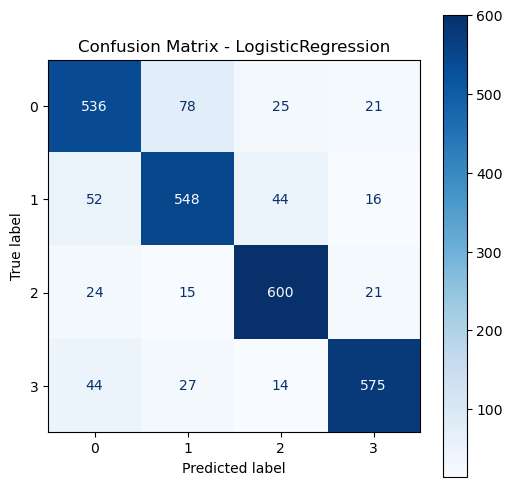

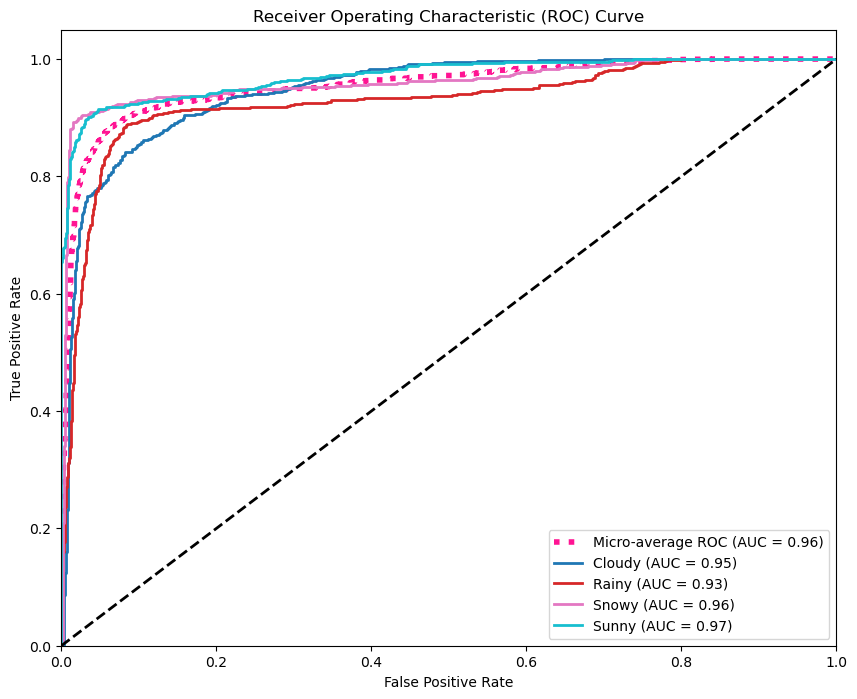

 11%|█████                                        | 1/9 [00:15<02:02, 15.35s/it]

──────────────────────────────────────────────────  Model: SVC  ───────────────────────────────────────────────────

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('classifier',
                                        SVC(probability=True,
                                            random_state=0))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.1, 1, 10],
                         'classifier__kernel': ['rbf', 'linear']},
             return_train_score=True, scoring='accuracy')

Classification Report for SVC:


              precision    recall  f1-score   support

           0       0.84      0.89      0.86       660
           1       0.90      0.88      0.89       660
           2       0.95      0.90      0.93       660
           3       0.90      0.90      0.90       660

    accuracy                           0.89      2640
   macro avg       0.90      0.89      0.90      2640
weighted avg       0.90      0.89      0.90      2640



Best parameters found: {'classifier__C': 1, 'classifier__kernel': 'rbf'}

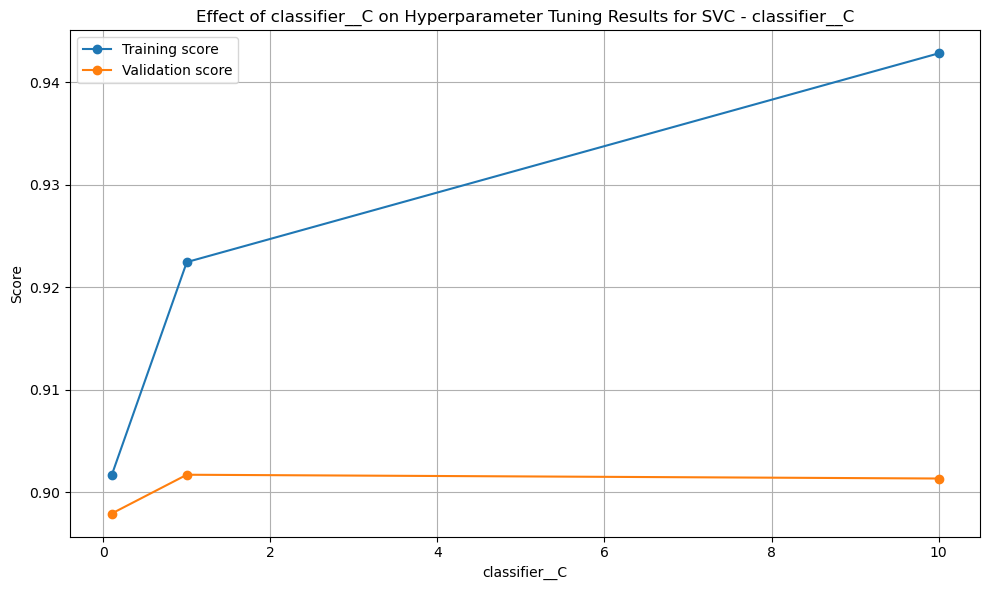

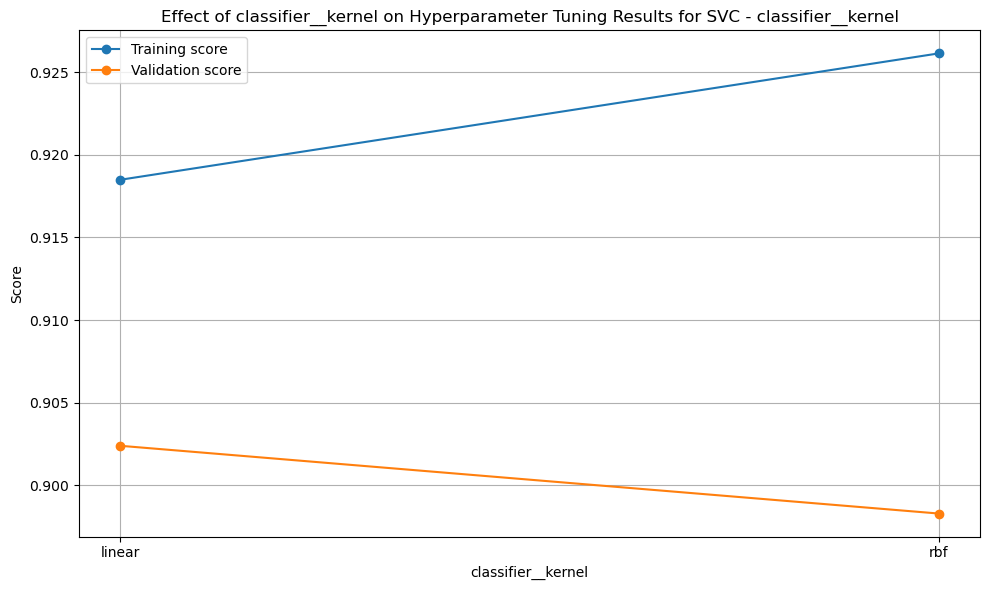

Confusion Matrix for SVC:

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'Confusion Matrix - SVC')

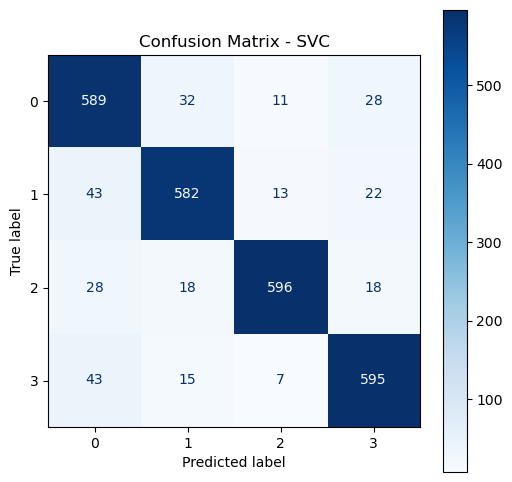

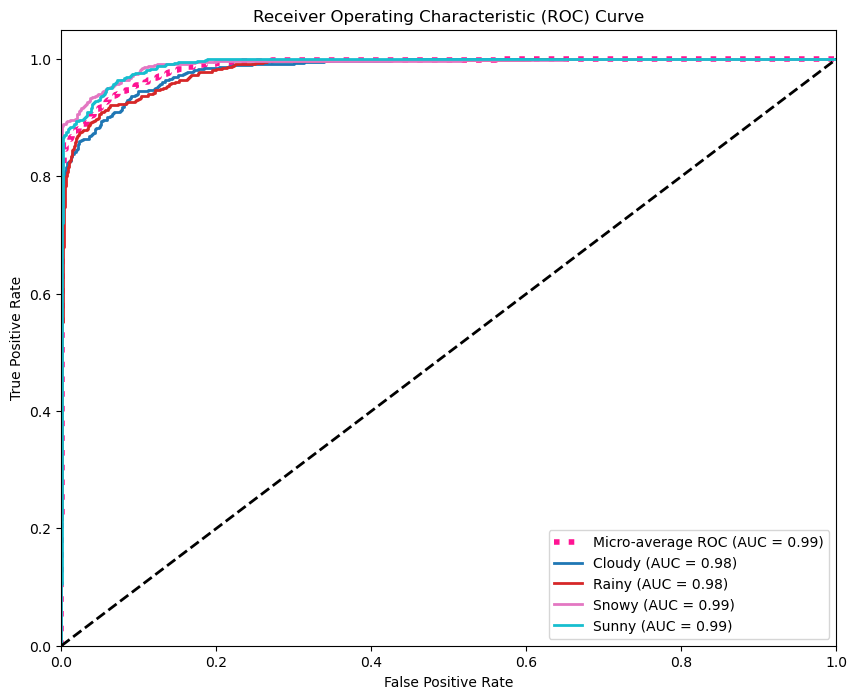

 22%|█████████▊                                  | 2/9 [04:11<16:57, 145.30s/it]

─────────────────────────────────────────  Model: RandomForestClassifier  ─────────────────────────────────────────

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('classifier',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=0))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [3, 5, 7],
                         'classifier__n_estimators': [50, 100, 200]},
             return_train_score=True, scoring='accuracy')

Classification Report for RandomForestClassifier:


              precision    recall  f1-score   support

           0       0.84      0.89      0.86       660
           1       0.86      0.90      0.88       660
           2       0.98      0.89      0.93       660
           3       0.92      0.91      0.92       660

    accuracy                           0.90      2640
   macro avg       0.90      0.90      0.90      2640
weighted avg       0.90      0.90      0.90      2640



Best parameters found: {'classifier__max_depth': 7, 'classifier__n_estimators': 100}

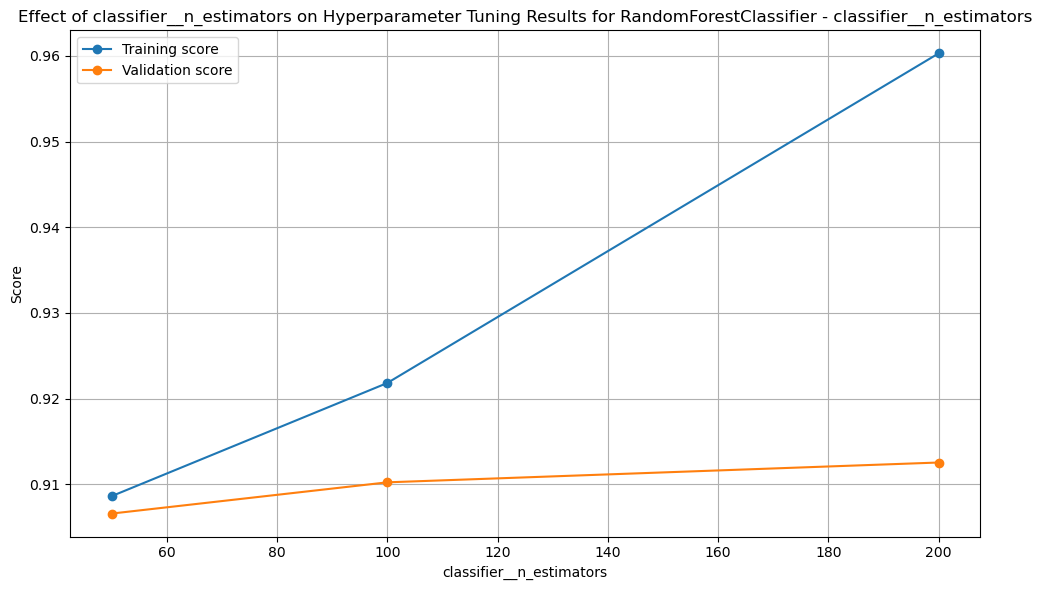

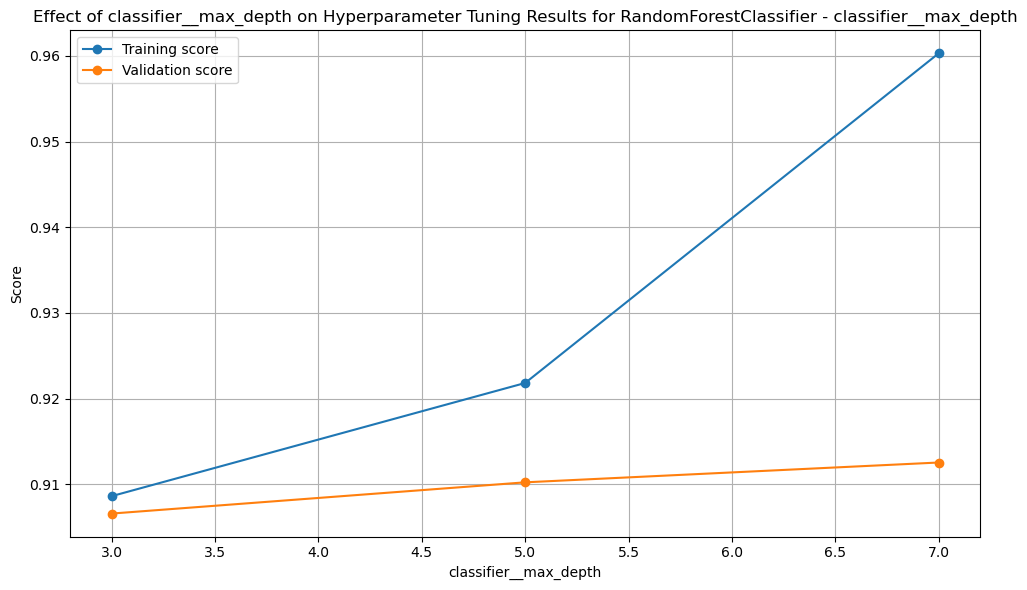

Confusion Matrix for RandomForestClassifier:

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'Confusion Matrix - RandomForestClassifier')

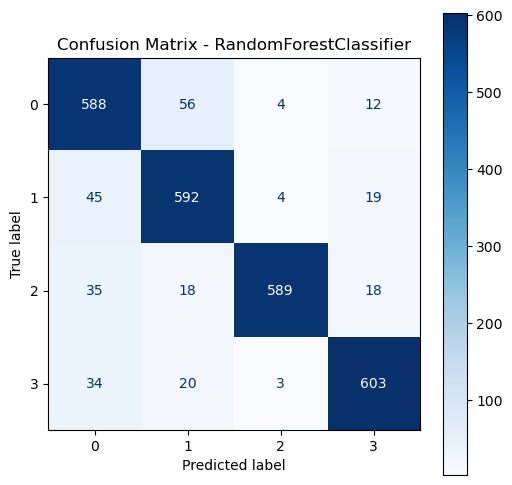

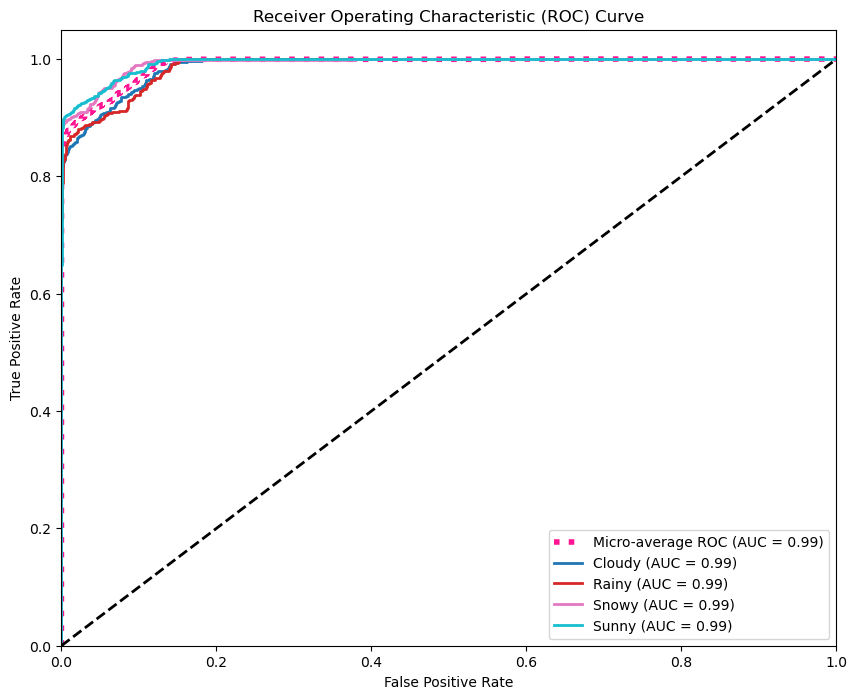

 33%|███████████████                              | 3/9 [04:37<09:05, 90.86s/it]

───────────────────────────────────────  Model: GradientBoostingClassifier  ───────────────────────────────────────

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('classifier',
                                        GradientBoostingClassifier(random_state=0))]),
             n_jobs=-1,
             param_grid={'classifier__learning_rate': [0.01, 0.1],
                         'classifier__n_estimators': [50, 100, 200]},
             return_train_score=True, scoring='accuracy')

Classification Report for GradientBoostingClassifier:


              precision    recall  f1-score   support

           0       0.89      0.88      0.88       660
           1       0.88      0.90      0.89       660
           2       0.94      0.91      0.92       660
           3       0.92      0.93      0.92       660

    accuracy                           0.90      2640
   macro avg       0.90      0.90      0.90      2640
weighted avg       0.90      0.90      0.90      2640



Best parameters found: {'classifier__learning_rate': 0.1, 'classifier__n_estimators': 100}

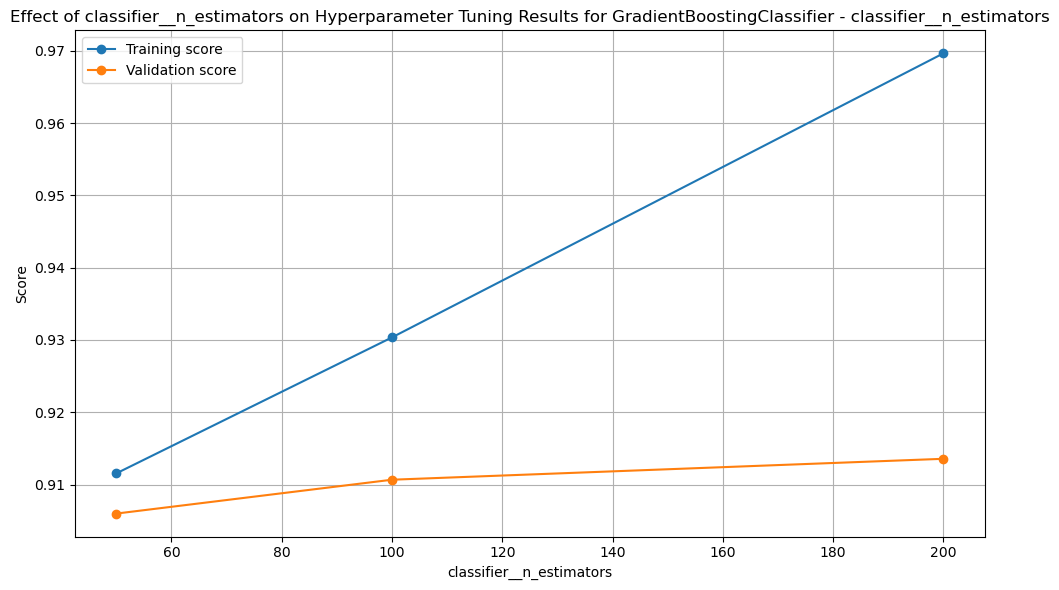

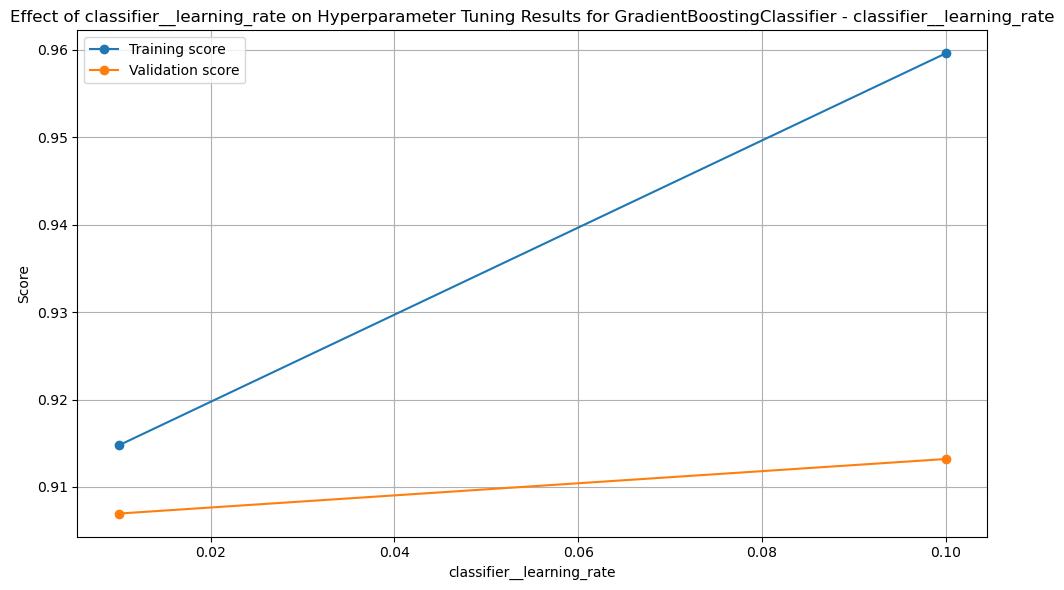

Confusion Matrix for GradientBoostingClassifier:

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'Confusion Matrix - GradientBoostingClassifier')

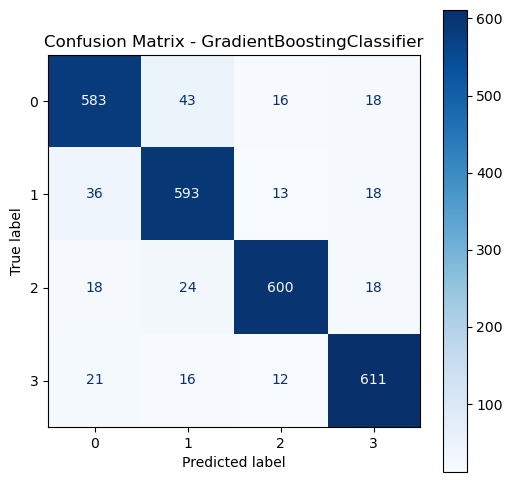

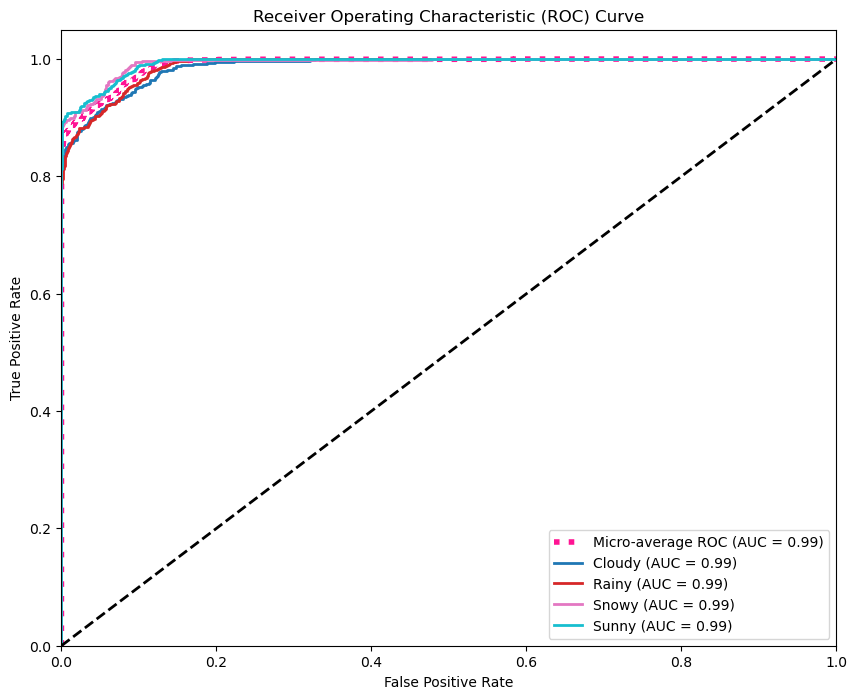

 44%|████████████████████                         | 4/9 [06:25<08:08, 97.62s/it]

─────────────────────────────────────────────  Model: XGBClassifier  ──────────────────────────────────────────────

/Users/sudhanshugarg/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:59:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/sudhanshugarg/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:59:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/sudhanshugarg/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:59:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/sudhanshugarg/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:59:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('classifier',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='mlogloss',
                                                      feature_types=None,
                                                      gamma=N...
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=-1,
                                                      num_parallel_tree=None,
                                                      random_state=0, ...))]),
             n_jobs=-1,
             param_grid={'classifier__learning_rate': [0.01, 0.1],
                         'classifier__max_depth': [3, 5],
                         'classifier__n_estimators': [50, 100]},
             return_train_score=True, scoring='accuracy')

Classification Report for XGBClassifier:


              precision    recall  f1-score   support

           0       0.89      0.89      0.89       660
           1       0.89      0.90      0.89       660
           2       0.94      0.91      0.92       660
           3       0.90      0.92      0.91       660

    accuracy                           0.90      2640
   macro avg       0.90      0.90      0.90      2640
weighted avg       0.90      0.90      0.90      2640



Best parameters found: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 
50}

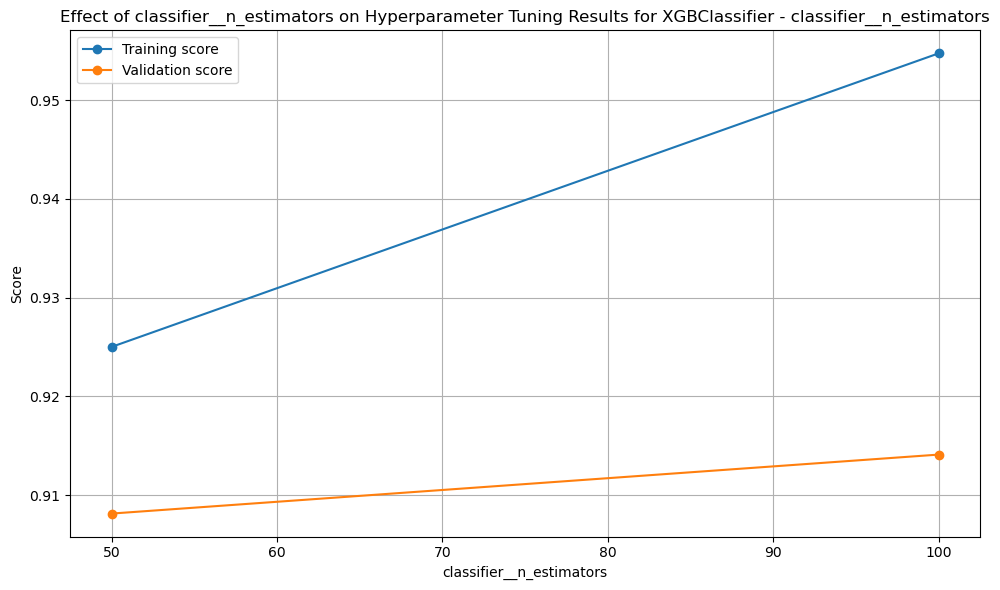

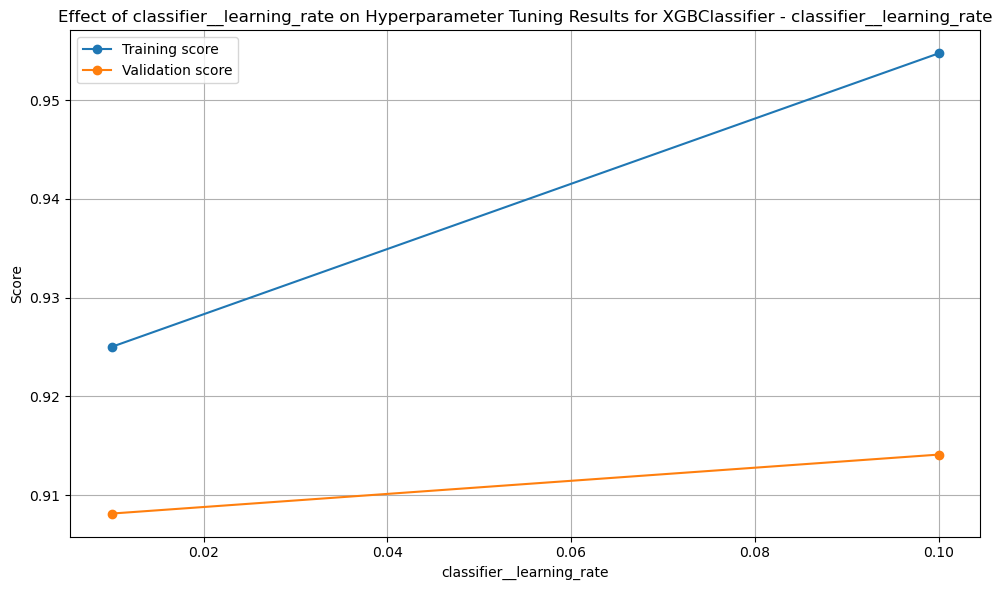

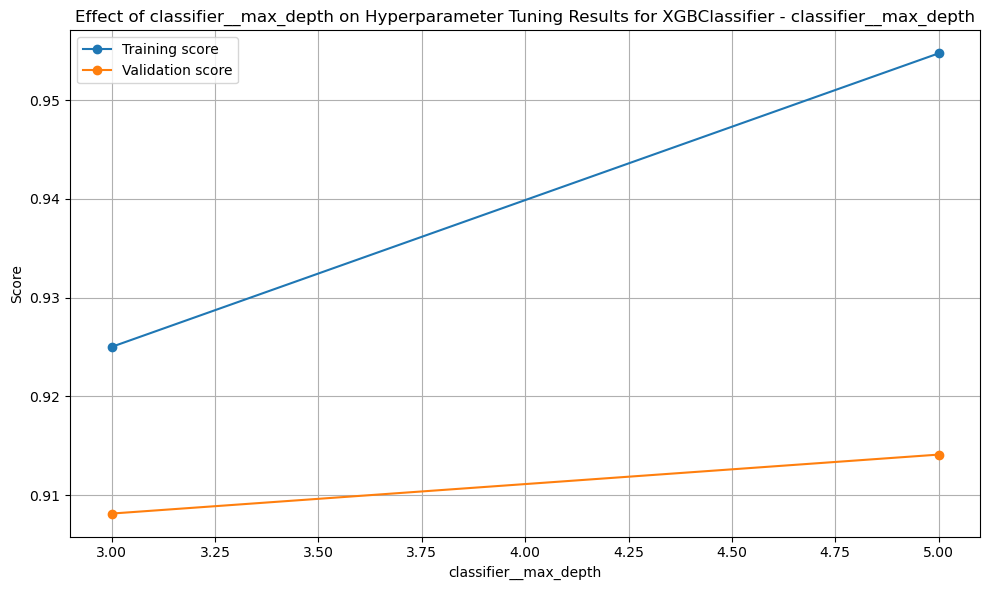

Confusion Matrix for XGBClassifier:

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'Confusion Matrix - XGBClassifier')

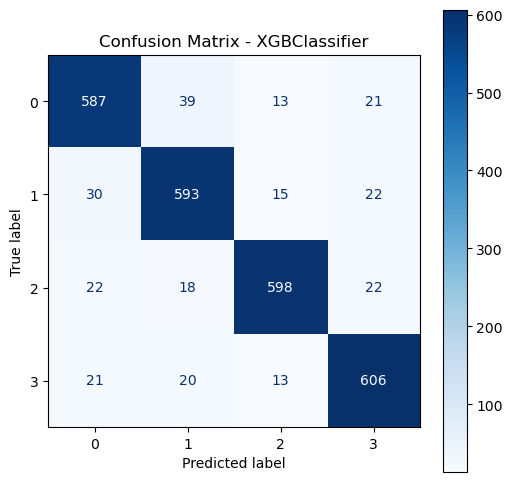

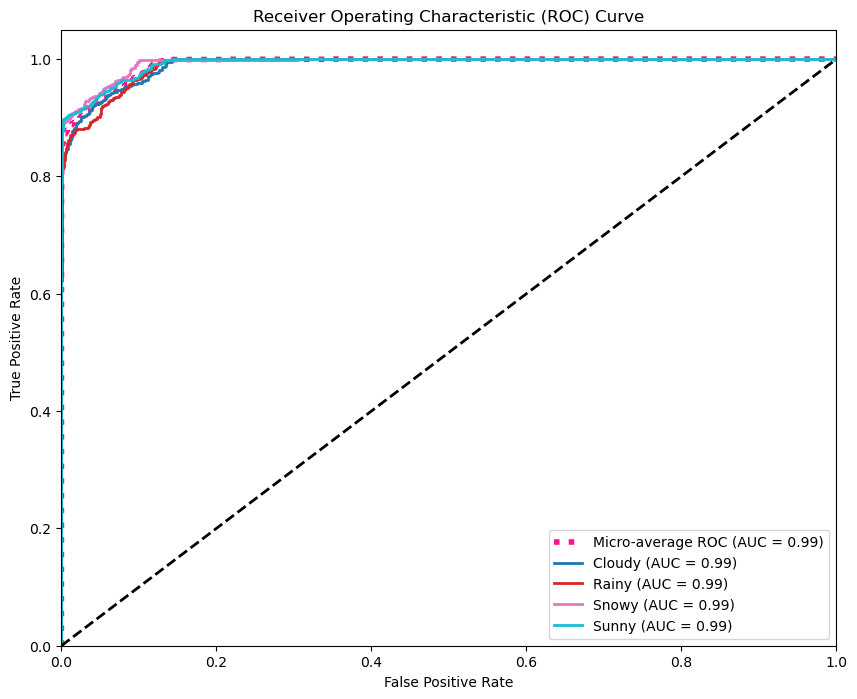

 56%|█████████████████████████                    | 5/9 [06:37<04:26, 66.54s/it]

─────────────────────────────────────────────  Model: LGBMClassifier  ─────────────────────────────────────────────

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('classifier',
                                        LGBMClassifier(random_state=0,
                                                       verbosity=-1))]),
             n_jobs=-1,
             param_grid={'classifier__learning_rate': [0.01, 0.1],
                         'classifier__max_depth': [3, 5],
                         'classifier__n_estimators': [50, 100]},
             return_train_score=True, scoring='accuracy')

Classification Report for LGBMClassifier:


              precision    recall  f1-score   support

           0       0.89      0.90      0.90       660
           1       0.89      0.90      0.89       660
           2       0.94      0.92      0.93       660
           3       0.91      0.92      0.92       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640



Best parameters found: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 
50}

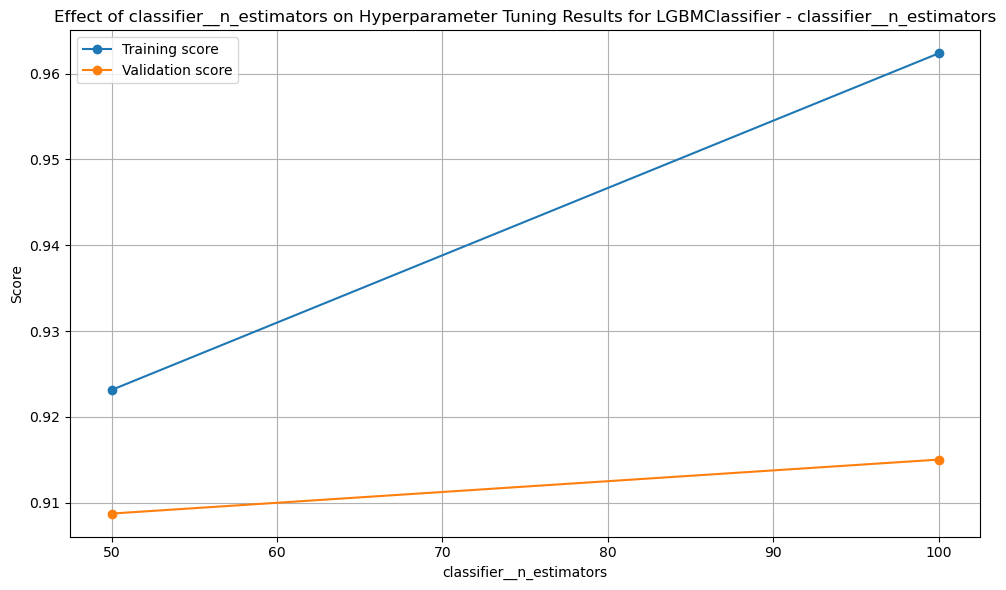

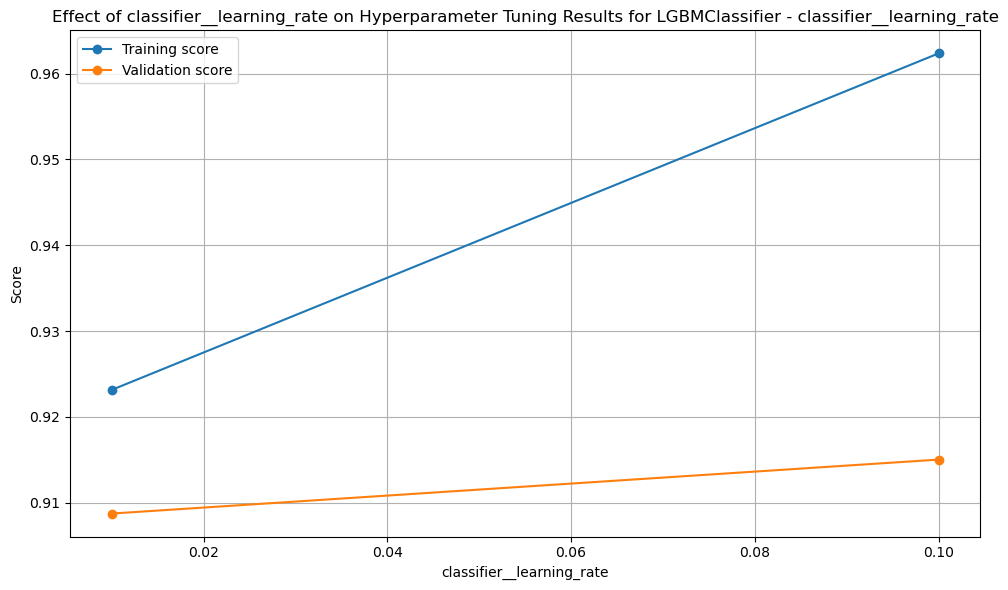

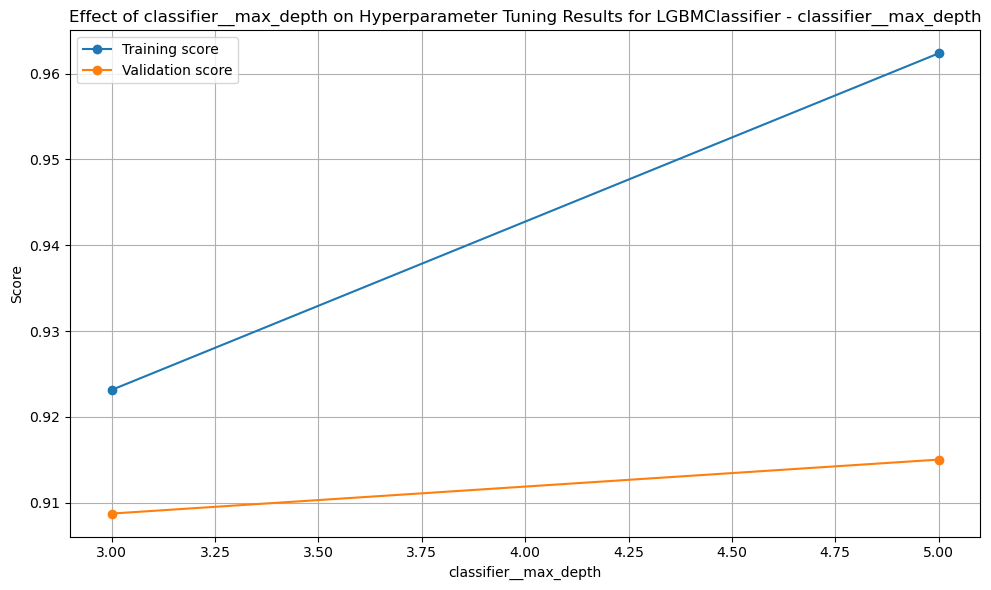

Confusion Matrix for LGBMClassifier:

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'Confusion Matrix - LGBMClassifier')

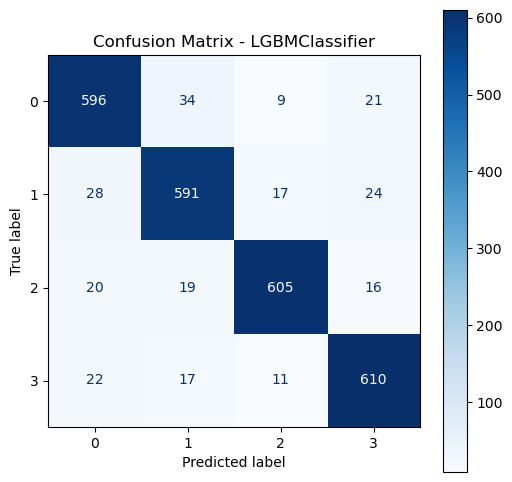

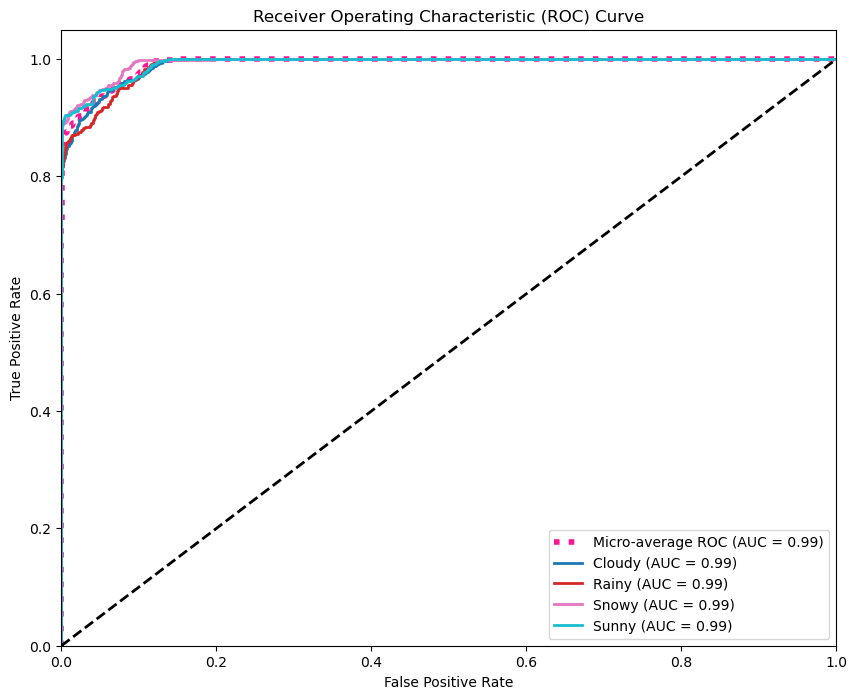

 67%|██████████████████████████████               | 6/9 [06:47<02:22, 47.57s/it]

───────────────────────────────────────────  Model: CatBoostClassifier  ───────────────────────────────────────────

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('classifier',
                                        <catboost.core.CatBoostClassifier object at 0x1334dcbd0>)]),
             n_jobs=-1,
             param_grid={'classifier__depth': [3, 5],
                         'classifier__iterations': [50, 100],
                         'classifier__learning_rate': [0.01, 0.1]},
             return_train_score=True, scoring='accuracy')

Classification Report for CatBoostClassifier:


              precision    recall  f1-score   support

           0       0.87      0.88      0.87       660
           1       0.88      0.88      0.88       660
           2       0.94      0.90      0.92       660
           3       0.91      0.93      0.92       660

    accuracy                           0.90      2640
   macro avg       0.90      0.90      0.90      2640
weighted avg       0.90      0.90      0.90      2640



Best parameters found: {'classifier__depth': 5, 'classifier__iterations': 100, 'classifier__learning_rate': 0.1}

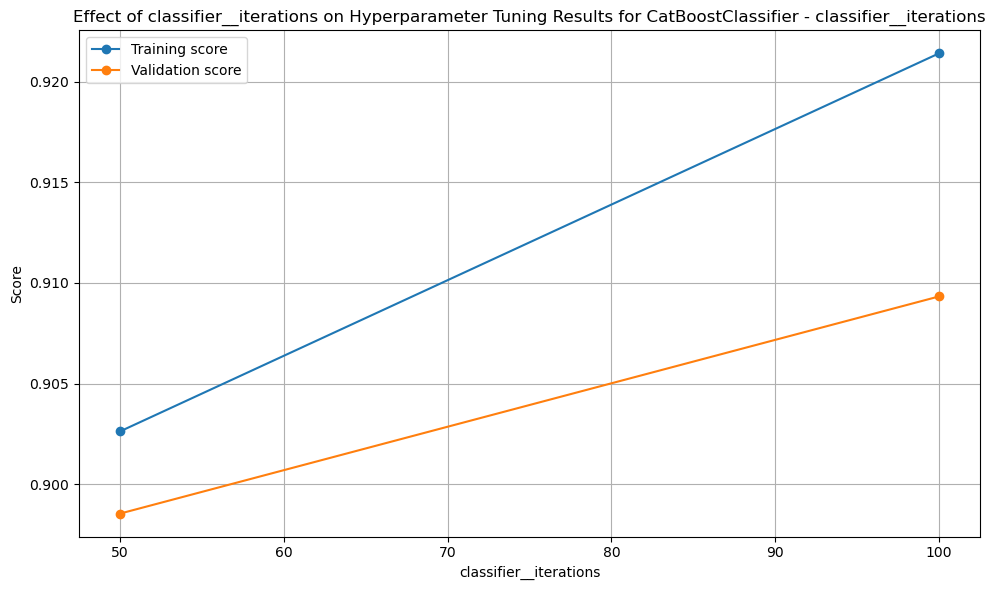

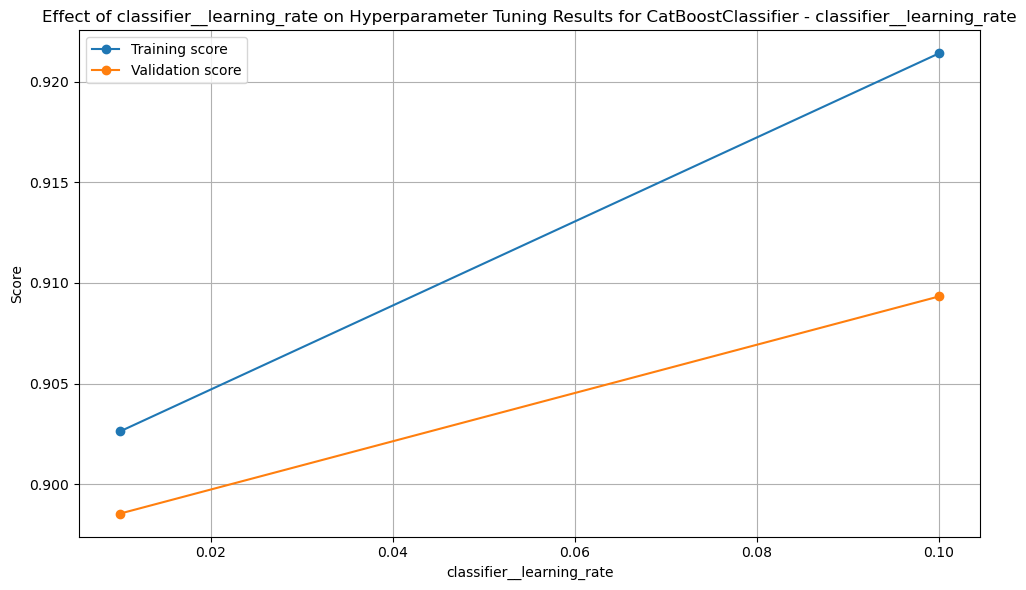

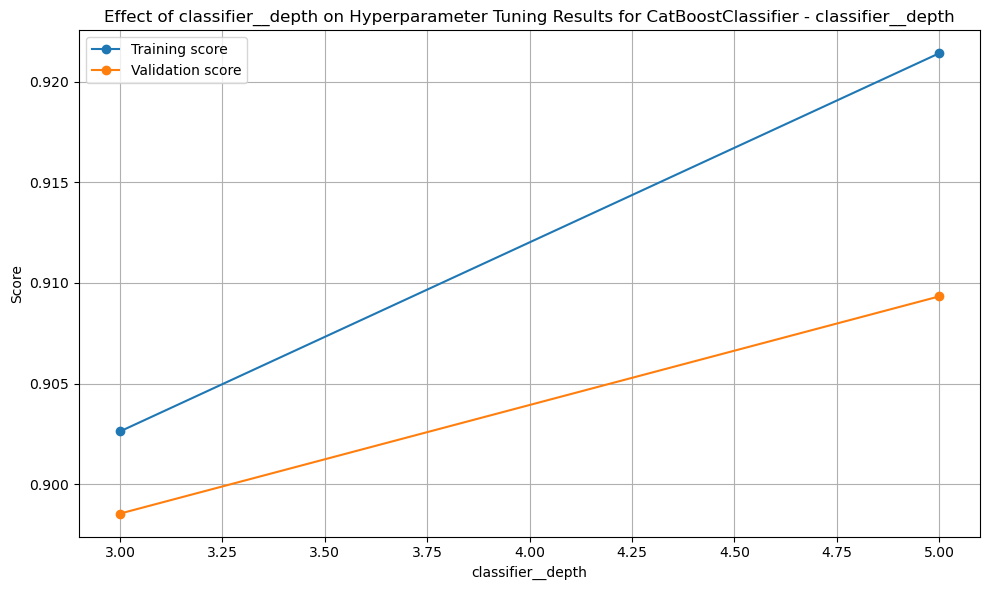

Confusion Matrix for CatBoostClassifier:

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'Confusion Matrix - CatBoostClassifier')

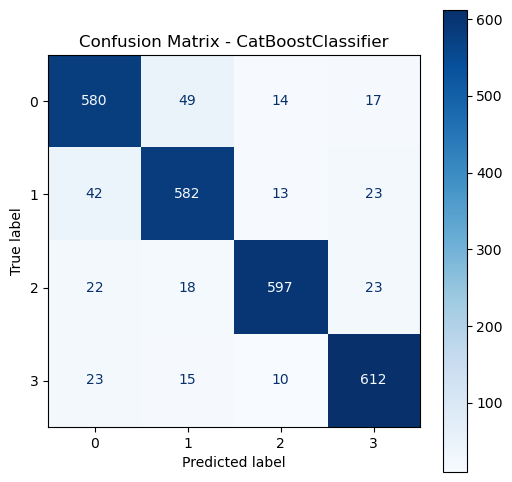

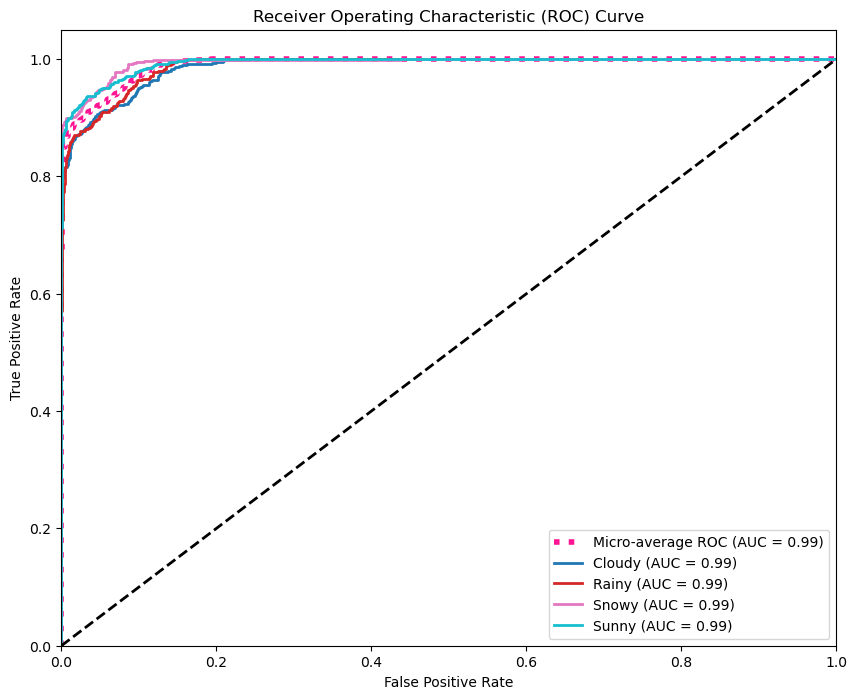

 78%|███████████████████████████████████          | 7/9 [07:01<01:13, 36.63s/it]

─────────────────────────────────────────  Model: DecisionTreeClassifier  ─────────────────────────────────────────

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('classifier',
                                        DecisionTreeClassifier(random_state=0))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [3, 5, 7, 10],
                         'classifier__min_samples_split': [2, 5, 10]},
             return_train_score=True, scoring='accuracy')

Classification Report for DecisionTreeClassifier:


              precision    recall  f1-score   support

           0       0.88      0.90      0.89       660
           1       0.90      0.89      0.90       660
           2       0.92      0.92      0.92       660
           3       0.93      0.92      0.92       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640



Best parameters found: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2}

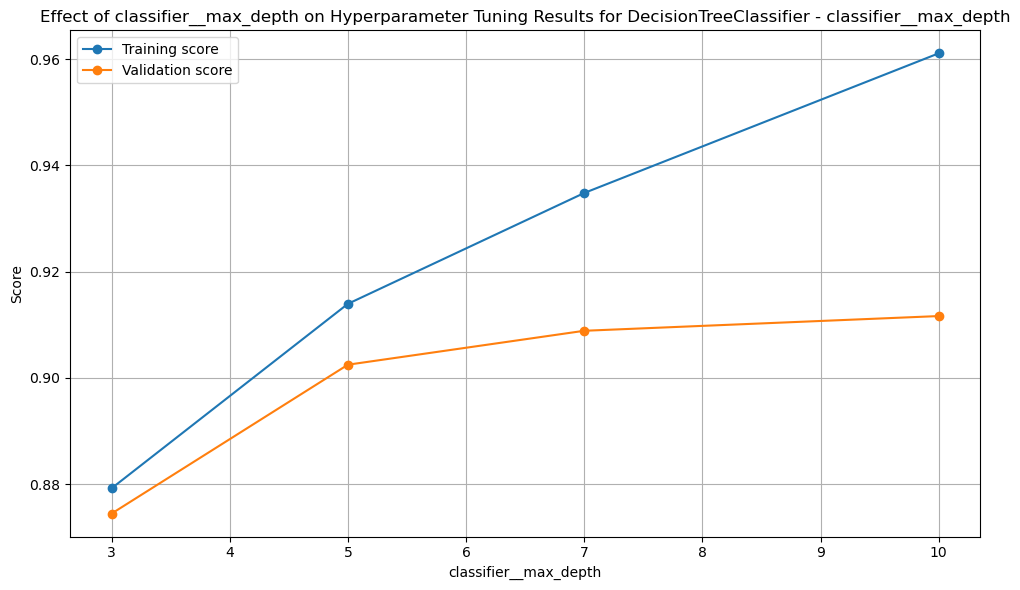

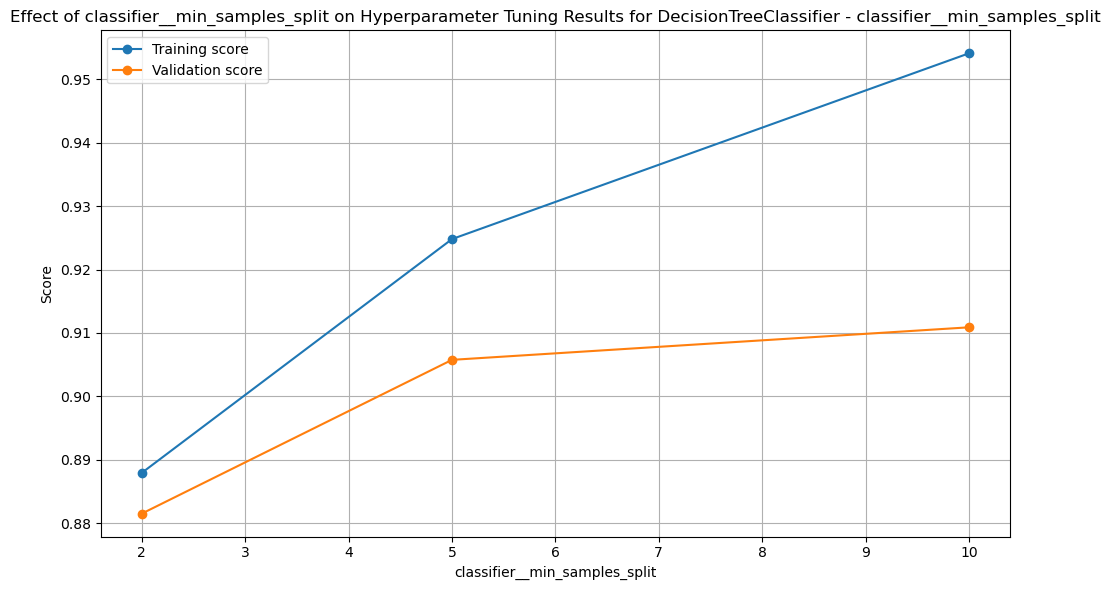

Confusion Matrix for DecisionTreeClassifier:

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'Confusion Matrix - DecisionTreeClassifier')

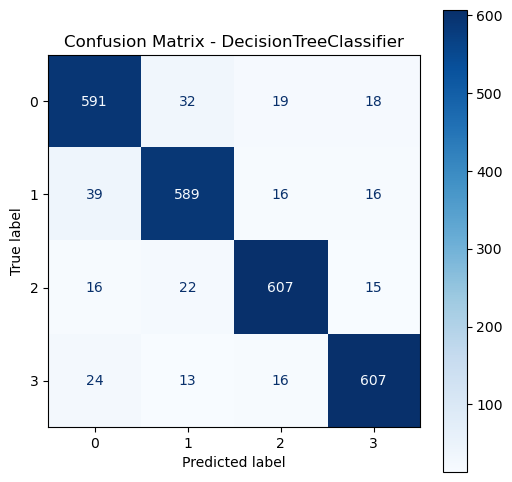

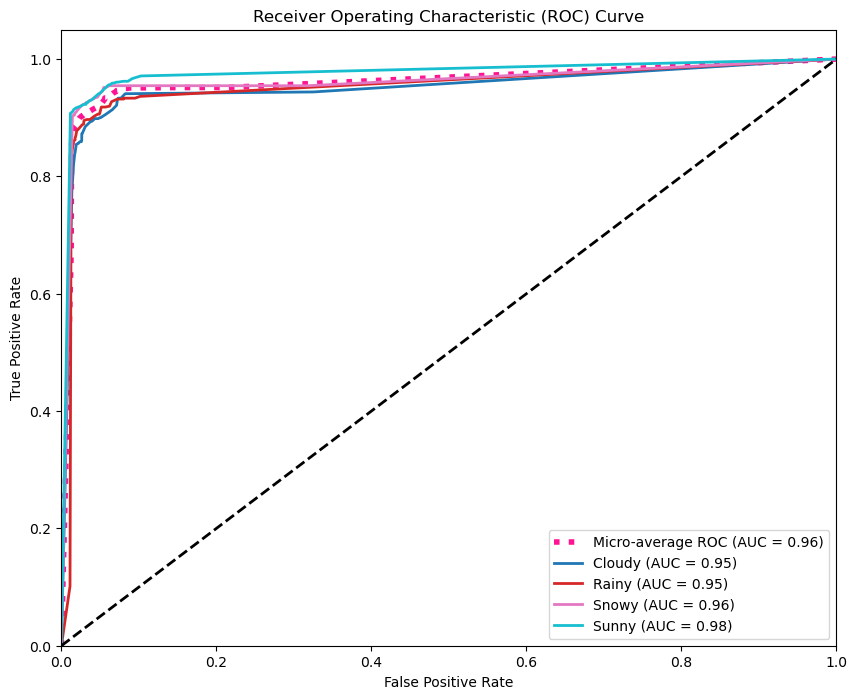

 89%|████████████████████████████████████████     | 8/9 [07:04<00:25, 25.90s/it]

──────────────────────────────────────────  Model: KNeighborsClassifier  ──────────────────────────────────────────

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('classifier',
                                        KNeighborsClassifier(n_jobs=-1))]),
             n_jobs=-1,
             param_grid={'classifier__n_neighbors': [3, 5, 7, 9],
                         'classifier__weights': ['uniform', 'distance']},
             return_train_score=True, scoring='accuracy')

Classification Report for KNeighborsClassifier:


              precision    recall  f1-score   support

           0       0.82      0.86      0.84       660
           1       0.84      0.87      0.85       660
           2       0.92      0.90      0.91       660
           3       0.92      0.88      0.90       660

    accuracy                           0.87      2640
   macro avg       0.88      0.87      0.88      2640
weighted avg       0.88      0.87      0.88      2640



Best parameters found: {'classifier__n_neighbors': 7, 'classifier__weights': 'uniform'}

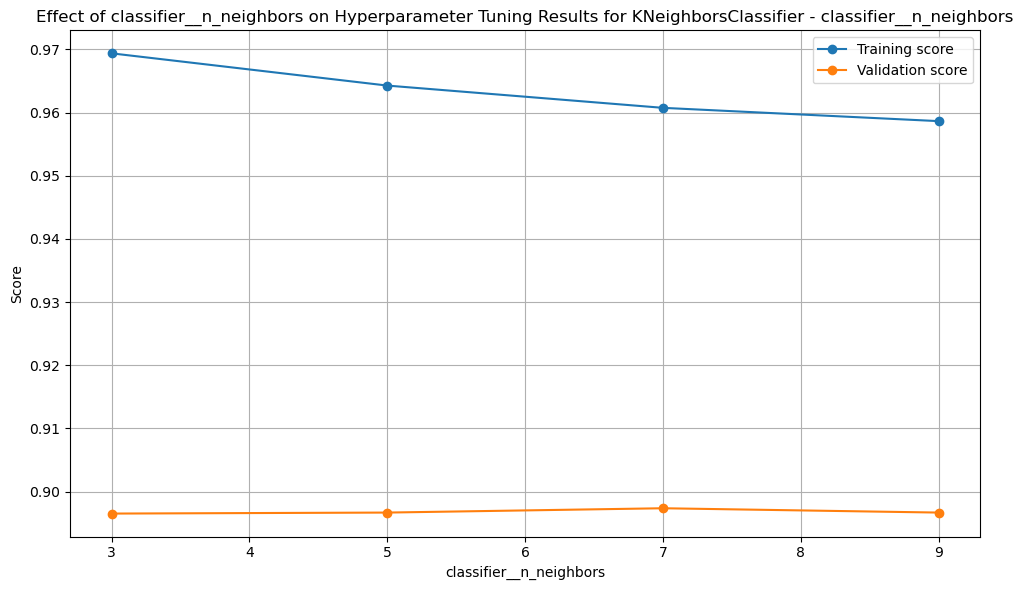

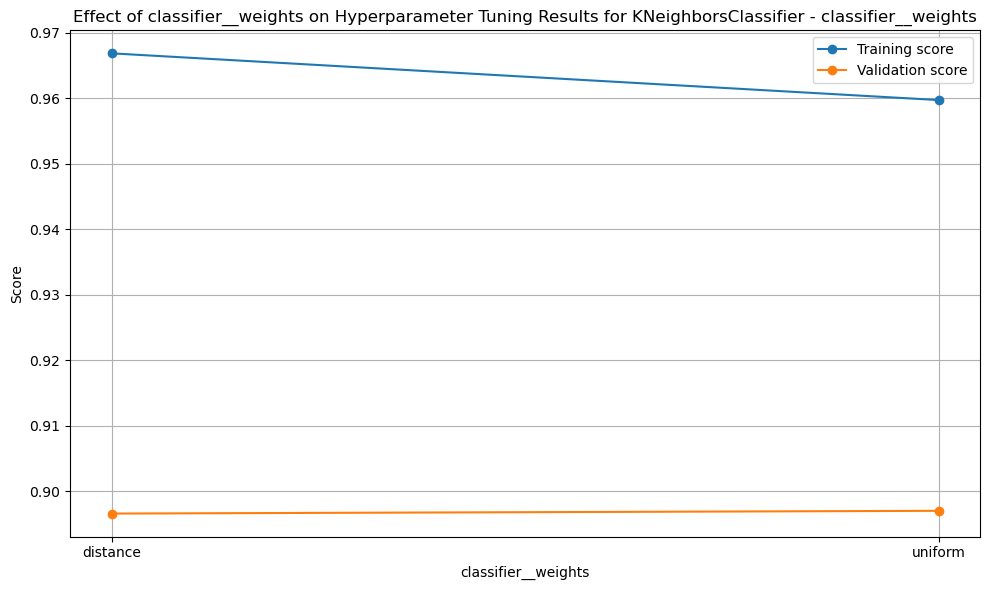

Confusion Matrix for KNeighborsClassifier:

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'Confusion Matrix - KNeighborsClassifier')

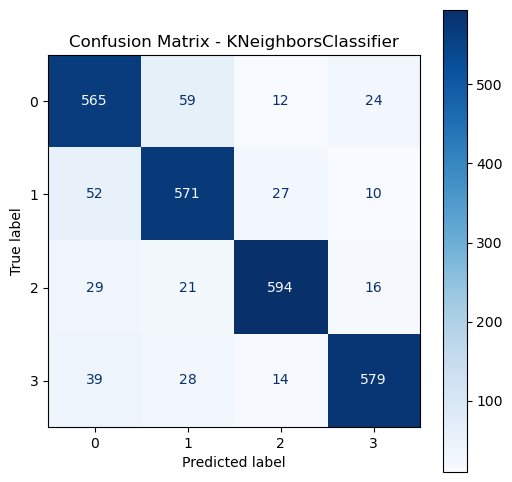

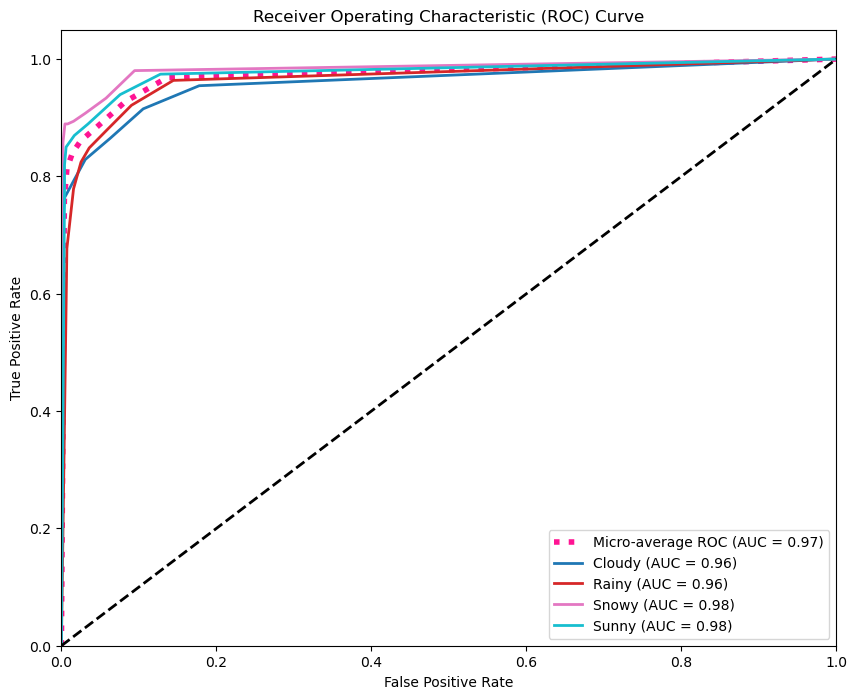

100%|█████████████████████████████████████████████| 9/9 [07:36<00:00, 50.70s/it]


In [36]:
# Model Training and Evaluation Iterations in for loop(to make the code neat, we used a loop for all models)
for name, model in tqdm(MODELS.items()):
    console.rule(f"[bold blue] Model: {name} [/bold blue]")

    # Defining thr pipeline
    pipeline = Pipeline(steps=[('classifier', model)])

    # Defining the grid search
    param_grid = PARAM_GRIDS[name]
    grid_search = GridSearchCV(pipeline, param_grid, scoring='accuracy', cv=cv, n_jobs=-1, verbose=0,return_train_score=True)

    # Performing grid search on training data
    grid_search.fit(X_train_df, y_train)

    # Getting the best model from grid search
    best_model = grid_search.best_estimator_

    # Calculating training accuracy
    y_train_pred = best_model.predict(X_train_df)
    training_accuracy = accuracy_score(y_train, y_train_pred)

    # Making predictions on the test set
    y_pred = best_model.predict(X_test_df)

    # Calculainge evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')  # Use 'weighted' for multi-class

    # Storing the results
    results.append({
        'Model': name,
        'Training Accuracy': training_accuracy,  # Added training accuracy
        'Test Accuracy': accuracy,
        'Test F1 Score': f1
    })

    # Printing classification report
    console.print(f"[bold green]Classification Report for {name}:[/bold green]")
    report = classification_report(y_test, y_pred)
    print(f"\n{report}")
    
    # Best parameters found
    console.print(f"Best parameters found: {grid_search.best_params_}")

        # Printing hyperparameter tuning results
    for param_name in param_grid.keys():
        try:
            plot = plot_param_tuning(grid_search.cv_results_, param_name, f'Hyperparameter Tuning Results for {name} - {param_name}')
            plot.show()
        except KeyError as e:
            console.print(f"[bold red]Error: {e}. Skipping plot for {param_name}.[/bold red]")
        except Exception as e:
            console.print(f"[bold red]Unexpected error: {e}. Skipping plot for {param_name}.[/bold red]")

    # Printing confusion matrix
    console.print(f"[bold green]Confusion Matrix for {name}:[/bold green]")
    plt.figure(figsize=(6, 6))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues, ax=plt.gca())
    plt.title(f'Confusion Matrix - {name}')
    plt.grid(False)
    plt.show()

    # Printing ROC Curve
    if hasattr(best_model.named_steps['classifier'], "predict_proba"):
        y_score = best_model.predict_proba(X_test_df)
        class_names = le.classes_
        roc_plot = plot_roc_curve(y_test, y_score, class_names)
        roc_plot.show()
    else:
        console.print("[bold yellow]Model does not support predict_proba, skipping ROC curve."
                      "[/bold yellow]")



In [62]:
results_df = pd.DataFrame(results)

In [64]:
# Sort the results by Test Accuracy and Test F1 Score
results_df = results_df.sort_values(by=['Test Accuracy', 'Test F1 Score'], ascending=[False,False])

In [66]:
# Select the desired columns for the final table
results_df = results_df[['Model', 'Training Accuracy', 'Test Accuracy', 'Test F1 Score']]

In [68]:
# Format the table using tabulate for better readability
table = tabulate(results_df, headers='keys', tablefmt='pipe', showindex=False,numalign='center', stralign='center')  
# Print the formatted table
print("\nModel Performance Summary:")
print(table)


Model Performance Summary:
|           Model            |  Training Accuracy  |  Test Accuracy  |  Test F1 Score  |
|:--------------------------:|:-------------------:|:---------------:|:---------------:|
|       LGBMClassifier       |      0.966961       |    0.909848     |    0.909916     |
|   DecisionTreeClassifier   |      0.965383       |    0.906818     |    0.906861     |
| GradientBoostingClassifier |       0.95181       |    0.904167     |    0.904257     |
|       XGBClassifier        |      0.964331       |     0.90303     |    0.903106     |
|   RandomForestClassifier   |      0.956229       |    0.898485     |    0.899302     |
|     CatBoostClassifier     |      0.940657       |    0.898106     |     0.89822     |
|            SVC             |      0.951073       |    0.894697     |    0.895129     |
|    KNeighborsClassifier    |      0.923822       |    0.874621     |    0.875087     |
|     LogisticRegression     |      0.875947       |    0.855682     |    0.855704

In [70]:
# Final Conclusion: Evaluate the best model according to both testing accuracy and F1 score
best_model_name = results_df.iloc[0]['Model']
best_model_accuracy = results_df.iloc[0]['Test Accuracy']
best_model_f1 = results_df.iloc[0]['Test F1 Score']

In [72]:
#Printing the final output
print("\n======================================================================")
print("Final Conclusion:")
print("======================================================================")
print(f"After evaluating all models, the {best_model_name} model stands out as the best"
      f" performer based on both testing accuracy and F1 score.")
print(f"- Test Accuracy: {best_model_accuracy:.4f}")
print(f"- Test F1 Score: {best_model_f1:.4f}")
print("This indicates that the model not only predicts the weather types accurately but also"
      " maintains a good balance between precision and recall, making it a reliable choice for"
      " this classification task.")



Final Conclusion:
After evaluating all models, the LGBMClassifier model stands out as the best performer based on both testing accuracy and F1 score.
- Test Accuracy: 0.9098
- Test F1 Score: 0.9099
This indicates that the model not only predicts the weather types accurately but also maintains a good balance between precision and recall, making it a reliable choice for this classification task.
